# GH2 Chile LCA — Brightway foreground model v6

**Goal:** Build a true Brightway foreground database for the Chilean green hydrogen export paper.

This notebook replaces the v3 screening layer with a **process-connected Brightway model**. Alan's EF 3.1 electricity and water factors are kept only as **validation benchmarks**, not as the calculation engine.

Main functional unit: **1 kg H₂-equivalent delivered**.

Pathways:

1. **Magallanes:** wind → H₂ → methanol → export
2. **Mejillones:** solar PV → H₂ → ammonia → export
3. Methanol sensitivity: **biogenic CO₂** and **DAC CO₂**

All impacts are calculated with Brightway for all matched EF 3.1 methods.


**v6 adds:** explicit/manual EF method mapping, all-27 impact relative plots, and Alan benchmark order-of-magnitude checks.

### v6 changes

- Uses new foreground database `GH2_Chile_v6_foreground` so it does not overwrite v6.
- Fixes ammonia nitrogen proxy selection by excluding nitrogen oxides, especially `dinitrogen tetroxide production`.
- Adds validation immediately after ammonia activity creation.
- Keeps Brightway LCIA as the source of all 27 EF impact estimates; Alan's factors remain validation references only.

## 0. Imports and global settings

In [1]:

from pathlib import Path
import re
import json
import math
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd

try:
    import brightway2 as bw
    BW_AVAILABLE = True
except Exception as e:
    BW_AVAILABLE = False
    print("Brightway import failed:", repr(e))

OUTPUT_DIR = Path("outputs_v6")
OUTPUT_DIR.mkdir(exist_ok=True)

# User choices confirmed by Pedro
# v6 note: fixes ammonia nitrogen proxy selection, avoiding dinitrogen tetroxide / nitrogen oxides.
PROJECT_NAME = "M23feb2025"             # edit if needed
SOURCE_DB_NAME = "Base2020_toH2_v2"     # premise output database, ecoinvent 3.10 cutoff
FOREGROUND_DB_NAME = "GH2_Chile_v6_foreground"
BIOSPHERE_DB_HINTS = ["biosphere3", "ecoinvent-3.10-biosphere"]

# Important flags
RESET_FOREGROUND_DB = True              # True = rebuild v6 foreground database from zero
AUTO_SELECT_FIRST_PROXY = True          # True = take first proxy candidate; False = force manual review
WRITE_PROXY_CANDIDATES = True
RUN_LCIA_AFTER_BUILD = True

# Main FU basis.
# "H2_feed_to_synthesis" = 1 kg H2 produced by electrolysis and converted into carrier.
# This is consistent with project H2 production data and avoids interpreting all carrier hydrogen atoms as recoverable H2.
H2_EQUIVALENCE_BASIS = "H2_feed_to_synthesis"

# Scenario assumptions
ASSUMPTIONS = {
    "electrolysis_kwh_per_kg_h2": 52.0,      # editable baseline
    "water_l_per_kg_h2_baseline": 10.0,
    "water_l_per_kg_h2_high": 35.0,
    "methanol_synthesis_kwh_per_kg_meoh": 0.50,  # proxy process energy, editable
    "ammonia_synthesis_kwh_per_kg_nh3": 0.60,    # Haber-Bosch compression/loop proxy, editable
    "shipping_return_trip_factor": 1.0,      # 1.0 one-way allocated; edit if empty return should be allocated
}

print("BW available:", BW_AVAILABLE)
print("Output dir:", OUTPUT_DIR.resolve())


BW available: True
Output dir: C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\general_LCA\outputs_v6


## 1. Alan project inputs and validation benchmarks

These values are used for:

- site metadata,
- route definitions,
- model assumptions,
- validation checks against Alan's SimaPro / EF 3.1 factors.

They are **not** used directly to compute final impacts in v6; final impacts are calculated by Brightway from connected proxy activities.


In [2]:

PROJECTS = {
    "MAG_WIND_METHANOL": {
        "label": "Magallanes: wind → H₂ → methanol",
        "region": "Magallanes",
        "site": "Tehuel Aike / Cabo Negro",
        "origin_port": "Puerto Cabo Negro",
        "renewable": "wind_onshore",
        "carrier": "methanol",
        "co2_cases": ["biogenic", "dac"],
        "water_mix": {"desalination": 1.0, "wastewater_reuse": 0.0},
        "project_reference": "HIF / Haru Oni",
        "wind_capacity_mw": 384,
        "capacity_factor": 0.57,
        "electrolyzer_capacity_mw": 242,
        "h2_t_per_year": 27830,
        "carrier_t_per_year": 175000,
    },
    "MEJ_SOLAR_AMMONIA": {
        "label": "Mejillones: solar PV → H₂ → ammonia",
        "region": "Antofagasta",
        "site": "Mejillones",
        "origin_port": "Puerto Mejillones",
        "renewable": "solar_pv",
        "carrier": "ammonia",
        "co2_cases": [None],
        "water_mix": {"desalination": 0.15, "wastewater_reuse": 0.85},
        "project_reference": "Mejillones Ammonia Energy / Volta",
        "pv_capacity_mw": 600,
        "electrolyzer_capacity_mw": 700,
    },
}

ROUTES = pd.DataFrame([
    ["Puerto Cabo Negro", "Los Angeles", 10898, 17],
    ["Puerto Cabo Negro", "Rotterdam", 13873, 22],
    ["Puerto Cabo Negro", "Kansai (Kobe)", 22426, 36],
    ["Puerto Mejillones", "Los Angeles", 8141, 13],
    ["Puerto Mejillones", "Rotterdam", 11062, 18],
    ["Puerto Mejillones", "Kansai (Kobe)", 23703, 38],
], columns=["origin_port", "destination", "distance_km", "transit_days"])

# Alan EF 3.1 factors per kWh or per m3 water. These are validation benchmarks only.
ALAN_FACTORS = pd.DataFrame([
    # impact_id, impact_category, unit, solar_antofagasta, wind_magallanes, desalination_water
    ["acidification", "Acidification", "mol H+ eq", 1.40E-04, 6.97625E-05, 1.16E-05],
    ["climate_change", "Climate change", "kg CO2 eq", 0.0216, 0.005841702, 0.00233],
    ["climate_change_biogenic", "Climate change - Biogenic", "kg CO2 eq", 6.27E-05, 8.38E-06, 1.25E-05],
    ["climate_change_fossil", "Climate change - Fossil", "kg CO2 eq", 0.0214, 5.82E-03, 0.00231],
    ["climate_change_land_use", "Climate change - Land use", "kg CO2 eq", 4.26E-05, 1.89E-05, 4.59E-06],
    ["ecotoxicity_freshwater_total", "Ecotoxicity, freshwater", "CTUe", 0.0871, 2.90E-02, 0.00472],
    ["ecotoxicity_freshwater_metals", "Ecotoxicity, freshwater - metals/inorganics", "CTUe", 0.1318, 5.77E-02, 0.00289],
    ["ecotoxicity_freshwater_inorganics", "Ecotoxicity, freshwater - inorganics", "CTUe", 0.2084, 8.13E-02, 0.00706],
    ["ecotoxicity_freshwater_organics", "Ecotoxicity, freshwater - organics", "CTUe", 0.0467, 2.15E-03, 0.000178],
    ["ecotoxicity_freshwater_organics_2", "Ecotoxicity, freshwater - organics 2", "CTUe", 5.06E-03, 3.16E-03, 0.000372],
    ["particulate_matter", "Particulate matter", "disease inc.", 1.41E-09, 6.23E-10, 1.01E-10],
    ["eutrophication_marine", "Eutrophication, marine", "kg N eq", 2.55E-05, 8.42E-06, 2.15E-06],
    ["eutrophication_freshwater", "Eutrophication, freshwater", "kg P eq", 1.31E-05, 5.46E-06, 1.01E-06],
    ["eutrophication_terrestrial", "Eutrophication, terrestrial", "mol N eq", 2.72E-04, 9.22E-05, 2.16E-05],
    ["human_toxicity_cancer", "Human toxicity, cancer", "CTUh", 2.41E-11, 2.58E-11, 7.69E-13],
    ["human_toxicity_cancer_inorganics", "Human toxicity, cancer - inorganics", "CTUh", 1.45E-11, 1.61E-11, 5.04E-13],
    ["human_toxicity_cancer_organics", "Human toxicity, cancer - organics", "CTUh", 9.59E-12, 9.63E-12, 2.65E-13],
    ["human_toxicity_non_cancer", "Human toxicity, non-cancer", "CTUh", 7.69E-10, 7.10E-10, 3.09E-11],
    ["human_toxicity_non_cancer_inorganics", "Human toxicity, non-cancer - inorganics", "CTUh", 7.49E-10, 6.78E-10, 2.91E-11],
    ["human_toxicity_non_cancer_organics", "Human toxicity, non-cancer - organics", "CTUh", 2.09E-11, 3.19E-11, 1.83E-12],
    ["ionising_radiation", "Ionising radiation", "kBq U-235 eq", 1.91E-03, 2.82E-04, 0.0003],
    ["land_use", "Land use", "Pt", 2.3296, 6.23E-02, 0.00522],
    ["ozone_depletion", "Ozone depletion", "kg CFC11 eq", 1.32E-09, 1.07E-10, 1.56E-08],
    ["photochemical_ozone_formation", "Photochemical ozone formation", "kg NMVOC eq", 9.05E-05, 3.23E-05, 6.50E-06],
    ["resource_use_fossils", "Resource use, fossils", "MJ", 0.2647, 6.61E-02, 0.0278],
    ["resource_use_minerals_metals", "Resource use, minerals and metals", "kg Sb eq", 1.71E-06, 7.12E-07, 1.47E-08],
    ["water_use", "Water use", "m3 depriv.", 0.0132, 2.27E-03, 0.00044],
], columns=["impact_id", "impact_category", "unit", "alan_solar_antofagasta_per_kwh", "alan_wind_magallanes_per_kwh", "alan_desalination_per_m3"])

print("Alan validation rows:", len(ALAN_FACTORS))
display(ALAN_FACTORS.head())
display(ROUTES)


Alan validation rows: 27


,impact_id,impact_category,unit,alan_solar_antofagasta_per_kwh,alan_wind_magallanes_per_kwh,alan_desalination_per_m3
0,acidification,Acidification,mol H+ eq,0.000140,0.000070,0.000012
1,climate_change,Climate change,kg CO2 eq,0.021600,0.005842,0.002330
2,climate_change_biogenic,Climate change - Biogenic,kg CO2 eq,0.000063,0.000008,0.000013
3,climate_change_fossil,Climate change - Fossil,kg CO2 eq,0.021400,0.005820,0.002310
4,climate_change_land_use,Climate change - Land use,kg CO2 eq,0.000043,0.000019,0.000005


,origin_port,destination,distance_km,transit_days
0,Puerto Cabo Negro,Los Angeles,10898,17
1,Puerto Cabo Negro,Rotterdam,13873,22
2,Puerto Cabo Negro,Kansai (Kobe),22426,36
3,Puerto Mejillones,Los Angeles,8141,13
4,Puerto Mejillones,Rotterdam,11062,18
5,Puerto Mejillones,Kansai (Kobe),23703,38


## 2. Stoichiometry and functional unit conversions

The default basis is **1 kg H₂ feed converted into carrier**. This matches project hydrogen production data.

- Methanol: CO₂ + 3H₂ → CH₃OH + H₂O
- Ammonia: N₂ + 3H₂ → 2NH₃


In [3]:

MOLAR = {
    "H2": 2.01588,
    "CO2": 44.0095,
    "MeOH": 32.0419,
    "N2": 28.0134,
    "NH3": 17.0305,
}

# per 1 kg H2 feed
CARRIER_CONVERSIONS = {
    "methanol": {
        "kg_carrier_per_kg_h2eq": MOLAR["MeOH"] / (3 * MOLAR["H2"]),
        "kg_co2_per_kg_h2eq": MOLAR["CO2"] / (3 * MOLAR["H2"]),
        "kg_n2_per_kg_h2eq": 0.0,
    },
    "ammonia": {
        "kg_carrier_per_kg_h2eq": (2 * MOLAR["NH3"]) / (3 * MOLAR["H2"]),
        "kg_co2_per_kg_h2eq": 0.0,
        "kg_n2_per_kg_h2eq": MOLAR["N2"] / (3 * MOLAR["H2"]),
    },
}

pd.DataFrame(CARRIER_CONVERSIONS).T


,kg_carrier_per_kg_h2eq,kg_co2_per_kg_h2eq,kg_n2_per_kg_h2eq
methanol,5.298249,7.277136,0.000000
ammonia,5.632114,0.000000,4.632121


## 3. Brightway setup and helper functions

In [4]:

if not BW_AVAILABLE:
    raise ImportError("Brightway is not available in this Python environment. Run this notebook in your Brightway environment.")

bw.projects.set_current(PROJECT_NAME)
print("Current project:", bw.projects.current)
print("Databases:")
for db in bw.databases:
    print(" -", db)

if SOURCE_DB_NAME not in bw.databases:
    raise ValueError(f"Source database {SOURCE_DB_NAME!r} not found. Available: {list(bw.databases)}")

source_db = bw.Database(SOURCE_DB_NAME)
print(f"Source DB {SOURCE_DB_NAME}: {len(source_db)} activities")


Current project: M23feb2025
Databases:
 - biosphere
 - ecoinvent-3.10-cutoff
 - ei_cutoff_3.10_remind_SSP2-NPi_2020_SPS1 2025-02-14
 - ei_cutoff_3.10_remind_SSP2-NPi_2020_SPS4 2025-02-14
 - ei_cutoff_3.10_remind_SSP2-NPi_2050_SPS1 2025-02-14
 - ei_cutoff_3.10_remind_SSP2-NPi_2050_SPS4 2025-02-14
 - ei_cutoff_3.10_remind_SSP2-PkBudg1150_2050_SPS1 2025-02-18
 - ei_cutoff_3.10_remind_SSP2-PkBudg500_2050_SPS1 2025-02-18
 - Base2020
 - Base2050
 - NetZero2050
 - Base2020_toH2
 - Base2020_toH2_v2
 - Chile_Household_Heating_v1
 - GH2_Chile_v4_foreground
 - GH2_Chile_v5_foreground
Source DB Base2020_toH2_v2: 31674 activities


In [5]:

def norm_text(x):
    return re.sub(r"\s+", " ", str(x).lower()).strip()

def activity_text(act):
    fields = [act.get("name", ""), act.get("reference product", ""), act.get("location", ""), act.get("unit", "")]
    return " | ".join(map(str, fields))

def find_candidates(db, include=None, exclude=None, location_contains=None, unit=None, preferred_unit=None, limit=50):
    """Find Brightway activities. `unit` is strict; `preferred_unit` only affects ranking."""
    include = [norm_text(t) for t in (include or [])]
    exclude = [norm_text(t) for t in (exclude or [])]
    loc = norm_text(location_contains) if location_contains else None
    rows = []
    for act in db:
        txt = norm_text(activity_text(act))
        if include and not all(t in txt for t in include):
            continue
        if exclude and any(t in txt for t in exclude):
            continue
        if loc and loc not in norm_text(act.get("location", "")):
            continue
        act_unit = norm_text(act.get("unit", ""))
        if unit and act_unit != norm_text(unit):
            continue
        score = 0
        # Prefer exact/compatible units, but don't discard candidates unless `unit` was strict.
        if preferred_unit and act_unit == norm_text(preferred_unit):
            score += 100
        # Prefer common generic/global datasets over very specific foreign provinces when no Chile proxy exists.
        loc_val = norm_text(act.get("location", ""))
        if loc_val in {"cl", "glo", "row", "rla", "world"}:
            score += 20
        # Prefer larger modern wind where applicable.
        txt_full = txt
        for good in [">3mw", "3mw", "onshore", "seawater", "reverse osmosis", "photovoltaic", "tanker", "chemical"]:
            if good in txt_full:
                score += 5
        for bad in ["<1mw", "offshore", "market group", "market for"]:
            if bad in txt_full:
                score -= 25
        rows.append({
            "score": score,
            "database": act.key[0],
            "code": act.key[1],
            "name": act.get("name"),
            "reference product": act.get("reference product"),
            "location": act.get("location"),
            "unit": act.get("unit"),
            "key": act.key,
        })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["score", "name"], ascending=[False, True]).head(limit)

def select_proxy(db, label, include, exclude=None, location_contains=None, unit=None, preferred_unit=None, limit=20):
    cands = find_candidates(
        db, include=include, exclude=exclude, location_contains=location_contains,
        unit=unit, preferred_unit=preferred_unit or unit, limit=limit
    )
    if cands.empty:
        raise LookupError(f"No proxy candidates found for {label}: include={include}, exclude={exclude}, location={location_contains}, unit={unit}")
    cands.insert(0, "proxy_label", label)
    if WRITE_PROXY_CANDIDATES:
        proxy_candidate_frames.append(cands.copy())
    print(f"\nProxy candidates for {label}: {len(cands)} shown")
    display(cands.drop(columns=["key"]).head(10))
    if not AUTO_SELECT_FIRST_PROXY:
        raise RuntimeError(f"Manual review requested. Choose a proxy for {label} from displayed candidates.")
    chosen = bw.get_activity(tuple(cands.iloc[0]["key"]))
    print("Selected:", chosen)
    return chosen

def select_proxy_strategies(db, label, strategies, preferred_unit=None, fallback=None, limit=20):
    """
    Try several search strategies. Each strategy can define include/exclude/unit/location_contains.
    `preferred_unit` only ranks candidates; it is not strict unless a strategy includes `unit`.
    """
    errors = []
    for s in strategies:
        try:
            return select_proxy(
                db, label,
                include=s.get("include", []),
                exclude=s.get("exclude"),
                location_contains=s.get("location_contains"),
                unit=s.get("unit"),
                preferred_unit=s.get("preferred_unit", preferred_unit),
                limit=limit,
            )
        except Exception as e:
            errors.append(str(e))
    if fallback is not None:
        warnings.warn(f"No good proxy found for {label}; using fallback {fallback}. Search errors: {errors[:2]}")
        return fallback
    raise LookupError(f"No proxy found for {label} after {len(strategies)} strategies. Last errors: {errors[-3:]}")

def recreate_foreground_db(name, reset=True):
    if name in bw.databases and reset:
        print(f"Deleting existing foreground database: {name}")
        del bw.databases[name]
    if name not in bw.databases:
        bw.Database(name).write({})
    return bw.Database(name)

def get_or_create_activity(db, code, name, unit, location="CL", reference_product=None):
    key = (db.name, code)
    if key in db:
        act = bw.get_activity(key)
        for exc in list(act.exchanges()):
            exc.delete()
    else:
        act = db.new_activity(code=code, name=name, unit=unit, location=location)
        act["reference product"] = reference_product or name
        act.save()
    act.new_exchange(input=act.key, amount=1.0, type="production", unit=unit).save()
    return act

def add_technosphere(act, input_act, amount, unit=None, comment=None):
    if input_act is None:
        warnings.warn(f"Skipped exchange for {act}: input activity is None. Comment: {comment}")
        return None
    exc = act.new_exchange(input=input_act.key, amount=float(amount), type="technosphere")
    if unit:
        exc["unit"] = unit
    if comment:
        exc["comment"] = comment
    exc.save()
    return exc

proxy_candidate_frames = []
fg = recreate_foreground_db(FOREGROUND_DB_NAME, reset=RESET_FOREGROUND_DB)
print("Foreground DB ready:", fg.name)


Foreground DB ready: GH2_Chile_v6_foreground


## 4. Select source proxy datasets from `Base2020_toH2_v2`

The model uses proxies as background activities. Review the selected candidates carefully.

If the first candidate is not appropriate, set `AUTO_SELECT_FIRST_PROXY = False`, inspect candidates, and manually adjust the search rules.


In [6]:

PROXIES = {}

# Electricity proxies. These are BW inventory proxies; Alan's factors are only validation benchmarks.
PROXIES["solar_pv"] = select_proxy_strategies(
    source_db,
    "solar_pv",
    strategies=[
        {"include": ["electricity production", "photovoltaic"], "exclude": ["market"], "unit": "kilowatt hour"},
        {"include": ["electricity", "photovoltaic"], "exclude": ["market"], "preferred_unit": "kilowatt hour"},
        {"include": ["photovoltaic"], "exclude": ["market"], "preferred_unit": "kilowatt hour"},
    ],
    preferred_unit="kilowatt hour",
)

PROXIES["wind_onshore"] = select_proxy_strategies(
    source_db,
    "wind_onshore",
    strategies=[
        {"include": ["electricity production", "wind", ">3MW", "onshore"], "exclude": ["market", "offshore", "<1MW"], "unit": "kilowatt hour"},
        {"include": ["electricity production", "wind", "onshore"], "exclude": ["market", "offshore", "<1MW"], "unit": "kilowatt hour"},
        {"include": ["electricity", "wind", "onshore"], "exclude": ["market", "offshore", "<1MW"], "preferred_unit": "kilowatt hour"},
        {"include": ["electricity production", "wind"], "exclude": ["market", "offshore", "<1MW"], "preferred_unit": "kilowatt hour"},
    ],
    preferred_unit="kilowatt hour",
)

# Water proxies. In some premise databases the Alan desalination dataset may have a different name/unit.
# We try increasingly broad searches and avoid stopping the notebook.
PROXIES["desalination"] = select_proxy_strategies(
    source_db,
    "desalination",
    strategies=[
        {"include": ["tap water production", "seawater reverse osmosis"], "preferred_unit": "cubic meter"},
        {"include": ["seawater", "reverse osmosis"], "preferred_unit": "cubic meter"},
        {"include": ["reverse osmosis"], "preferred_unit": "cubic meter"},
        {"include": ["desalination"], "preferred_unit": "cubic meter"},
        {"include": ["tap water", "seawater"], "preferred_unit": "cubic meter"},
        {"include": ["tap water production"], "preferred_unit": "cubic meter"},
        {"include": ["water production"], "preferred_unit": "cubic meter"},
    ],
    preferred_unit="cubic meter",
)

try:
    PROXIES["wastewater_reuse"] = select_proxy_strategies(
        source_db,
        "wastewater_reuse",
        strategies=[
            {"include": ["wastewater", "treatment"], "exclude": ["market"], "preferred_unit": "cubic meter"},
            {"include": ["wastewater"], "exclude": ["market"], "preferred_unit": "cubic meter"},
            {"include": ["water", "treatment"], "exclude": ["market"], "preferred_unit": "cubic meter"},
        ],
        preferred_unit="cubic meter",
        fallback=PROXIES["desalination"],
    )
except Exception as e:
    warnings.warn(f"Wastewater reuse proxy not found; falling back to desalination. Reason: {e}")
    PROXIES["wastewater_reuse"] = PROXIES["desalination"]

# Gas/material proxies
# v6: nitrogen proxy selection is specialized because the broad search in v6.1 could select
# `dinitrogen tetroxide production`, which is NOT the N2 input for green ammonia synthesis.
def select_nitrogen_proxy(db, limit=80):
    rows = []
    banned_terms = [
        "tetroxide", "dioxide", "oxide", "monoxide", "nitrous", "nitric",
        "nitrate", "fertiliser", "fertilizer", "ammonia", "nutrient"
    ]
    for act in db:
        name = norm_text(act.get("name", ""))
        ref = norm_text(act.get("reference product", ""))
        unit = norm_text(act.get("unit", ""))
        txt = f"{name} | {ref}"
        if "nitrogen" not in txt:
            continue
        if unit != "kilogram":
            continue
        if any(bad in txt for bad in banned_terms):
            continue
        score = 0
        if ref in {"nitrogen", "nitrogen, liquid", "nitrogen, gaseous", "nitrogen gas"}:
            score += 100
        if "market for nitrogen" in name:
            score += 60
        if "nitrogen production" in name or "air separation" in name:
            score += 50
        loc = norm_text(act.get("location", ""))
        if loc in {"glo", "row", "rla", "rer", "cl"}:
            score += 15
        rows.append({
            "score": score,
            "database": act.key[0],
            "code": act.key[1],
            "name": act.get("name"),
            "reference product": act.get("reference product"),
            "location": act.get("location"),
            "unit": act.get("unit"),
            "key": act.key,
        })
    if not rows:
        raise LookupError("No suitable nitrogen gas proxy found. Check source DB for nitrogen/air separation datasets.")
    cands = pd.DataFrame(rows).sort_values(["score", "name"], ascending=[False, True]).head(limit)
    cands.insert(0, "proxy_label", "nitrogen")
    if WRITE_PROXY_CANDIDATES:
        proxy_candidate_frames.append(cands.copy())
    print(f"\nProxy candidates for nitrogen gas: {len(cands)} shown")
    display(cands.drop(columns=["key"]).head(15))
    if not AUTO_SELECT_FIRST_PROXY:
        raise RuntimeError("Manual review requested. Choose a nitrogen proxy from displayed candidates.")
    chosen = bw.get_activity(tuple(cands.iloc[0]["key"]))
    print("Selected nitrogen proxy:", chosen)
    return chosen

try:
    PROXIES["nitrogen"] = select_nitrogen_proxy(source_db)
except Exception as e:
    warnings.warn(f"Nitrogen proxy not found; ammonia model will miss N2 supply unless fixed. Reason: {e}")
    PROXIES["nitrogen"] = None

# CO2 source proxies for methanol sensitivity
try:
    PROXIES["co2_dac"] = select_proxy_strategies(
        source_db,
        "co2_dac",
        strategies=[
            {"include": ["carbon dioxide", "capture", "air"], "preferred_unit": "kilogram"},
            {"include": ["direct air capture"], "preferred_unit": "kilogram"},
            {"include": ["carbon dioxide", "capture"], "preferred_unit": "kilogram"},
        ],
        preferred_unit="kilogram",
    )
except Exception as e:
    warnings.warn(f"No DAC proxy selected. DAC methanol case will fail unless fixed. Reason: {e}")
    PROXIES["co2_dac"] = None

try:
    PROXIES["co2_biogenic"] = select_proxy_strategies(
        source_db,
        "co2_biogenic",
        strategies=[
            {"include": ["carbon dioxide", "biogenic"], "preferred_unit": "kilogram"},
            {"include": ["carbon dioxide", "capture", "biomass"], "preferred_unit": "kilogram"},
            {"include": ["carbon dioxide", "capture"], "preferred_unit": "kilogram"},
        ],
        preferred_unit="kilogram",
    )
except Exception as e:
    warnings.warn(f"No biogenic CO2 proxy selected. Biogenic methanol case will use DAC/fallback if available. Reason: {e}")
    PROXIES["co2_biogenic"] = PROXIES.get("co2_dac")

# Transport proxies. Use chemical/tanker where available, otherwise generic sea freight.
PROXIES["transport_methanol_tanker"] = select_proxy_strategies(
    source_db,
    "transport_methanol_tanker",
    strategies=[
        {"include": ["transport", "freight", "sea", "chemical tanker"], "preferred_unit": "ton kilometer"},
        {"include": ["transport", "freight", "sea", "tanker"], "preferred_unit": "ton kilometer"},
        {"include": ["transport", "freight", "sea"], "preferred_unit": "ton kilometer"},
        {"include": ["transport", "sea"], "preferred_unit": "ton kilometer"},
    ],
    preferred_unit="ton kilometer",
)

try:
    PROXIES["transport_ammonia_tanker"] = select_proxy_strategies(
        source_db,
        "transport_ammonia_tanker",
        strategies=[
            {"include": ["transport", "freight", "sea", "ammonia"], "preferred_unit": "ton kilometer"},
            {"include": ["transport", "freight", "sea", "chemical tanker"], "preferred_unit": "ton kilometer"},
            {"include": ["transport", "freight", "sea", "tanker"], "preferred_unit": "ton kilometer"},
        ],
        preferred_unit="ton kilometer",
        fallback=PROXIES["transport_methanol_tanker"],
    )
except Exception as e:
    warnings.warn(f"Ammonia tanker proxy not found; using methanol/generic tanker proxy. Reason: {e}")
    PROXIES["transport_ammonia_tanker"] = PROXIES["transport_methanol_tanker"]

# Optional heat proxy for synthesis; fallback no heat if not selected
try:
    PROXIES["heat_industrial"] = select_proxy_strategies(
        source_db,
        "heat_industrial",
        strategies=[
            {"include": ["heat", "industrial"], "exclude": ["market"], "preferred_unit": "megajoule"},
            {"include": ["heat production"], "exclude": ["market"], "preferred_unit": "megajoule"},
            {"include": ["heat"], "exclude": ["market"], "preferred_unit": "megajoule"},
        ],
        preferred_unit="megajoule",
    )
except Exception as e:
    warnings.warn(f"Heat proxy not found; synthesis will only include electricity and feedstocks. Reason: {e}")
    PROXIES["heat_industrial"] = None

if proxy_candidate_frames:
    proxy_candidates = pd.concat(proxy_candidate_frames, ignore_index=True)
    proxy_candidates.drop(columns=["key"]).to_excel(OUTPUT_DIR / "proxy_candidates_v6_1.xlsx", index=False)

selected_proxy_rows = []
for k, act in PROXIES.items():
    if act is None:
        selected_proxy_rows.append([k, None, None, None, None, None, None])
    else:
        selected_proxy_rows.append([k, act.key[0], act.key[1], act.get("name"), act.get("reference product"), act.get("location"), act.get("unit")])
selected_proxies = pd.DataFrame(selected_proxy_rows, columns=["proxy", "database", "code", "name", "reference_product", "location", "unit"])
display(selected_proxies)
selected_proxies.to_excel(OUTPUT_DIR / "selected_proxies_v6_1.xlsx", index=False)



Proxy candidates for solar_pv: 20 shown


,proxy_label,score,database,code,name,reference product,location,unit
158,solar_pv,125,Base2020_toH2_v2,use_phase,"electricity production, photovoltaic, 0.28kWp,...","electricity production, photovoltaic, 0.28kWp,...",GLO,kilowatt hour
300,solar_pv,125,Base2020_toH2_v2,d96c2bd745ccbf4b3690edc1a96cda53,"electricity production, photovoltaic, 3kWp fac...","electricity, low voltage",RoW,kilowatt hour
387,solar_pv,125,Base2020_toH2_v2,41fd09a301e01580ae5f7ce433c546ef,"electricity production, photovoltaic, 3kWp fac...","electricity, low voltage",RoW,kilowatt hour
11,solar_pv,125,Base2020_toH2_v2,c248a9fd55b610995471123ef3eb0ac3,"electricity production, photovoltaic, 3kWp fac...","electricity, low voltage",RoW,kilowatt hour
2,solar_pv,125,Base2020_toH2_v2,775f4ea6d8af3e119182ffd3201b0abf,"electricity production, photovoltaic, 3kWp fac...","electricity, low voltage",RoW,kilowatt hour
351,solar_pv,125,Base2020_toH2_v2,2de2b12ecb886a009185eef04c6910a9,"electricity production, photovoltaic, 3kWp fla...","electricity, low voltage",RoW,kilowatt hour
189,solar_pv,125,Base2020_toH2_v2,4da94a91ccddc105dae37b7383fe69da,"electricity production, photovoltaic, 3kWp fla...","electricity, low voltage",RoW,kilowatt hour
369,solar_pv,125,Base2020_toH2_v2,7c2c7223b5dfd7c9c72f8ceeded5a2ff,"electricity production, photovoltaic, 3kWp sla...","electricity, low voltage",RoW,kilowatt hour
247,solar_pv,125,Base2020_toH2_v2,ca7611b11b37b2991da2d5dae8ecdd0f,"electricity production, photovoltaic, 3kWp sla...","electricity, low voltage",RoW,kilowatt hour
203,solar_pv,125,Base2020_toH2_v2,164ba92e10dc8a56b69cac60198251b3,"electricity production, photovoltaic, 3kWp sla...","electricity, low voltage",RoW,kilowatt hour


Selected: 'electricity production, photovoltaic, 0.28kWp, GaAs' (kilowatt hour, GLO, None)

Proxy candidates for wind_onshore: 20 shown


,proxy_label,score,database,code,name,reference product,location,unit
38,wind_onshore,135,Base2020_toH2_v2,569413eeb8b5ffa2900170f21006b433,"electricity production, wind, >3MW turbine, on...","electricity, high voltage",CL,kilowatt hour
55,wind_onshore,135,Base2020_toH2_v2,7a41577cbdd1a76017facf240702d009,"electricity production, wind, >3MW turbine, on...","electricity, high voltage",RoW,kilowatt hour
0,wind_onshore,115,Base2020_toH2_v2,d362ee5a74fed9a20b7a6b1e9041f2c8,"electricity production, wind, >3MW turbine, on...","electricity, high voltage",CA-PE,kilowatt hour
1,wind_onshore,115,Base2020_toH2_v2,abeebd574779141e84de42b2ac50b80a,"electricity production, wind, >3MW turbine, on...","electricity, high voltage",CN-SH,kilowatt hour
2,wind_onshore,115,Base2020_toH2_v2,4e05fc1d7442a629d200b333ab350906,"electricity production, wind, >3MW turbine, on...","electricity, high voltage",US-SERC,kilowatt hour
3,wind_onshore,115,Base2020_toH2_v2,e4523a7c761e0777e36fadb7ddef9294,"electricity production, wind, >3MW turbine, on...","electricity, high voltage",CY,kilowatt hour
4,wind_onshore,115,Base2020_toH2_v2,37bf4dbe9b54aea9a7c28803fa204de2,"electricity production, wind, >3MW turbine, on...","electricity, high voltage",CA-NS,kilowatt hour
5,wind_onshore,115,Base2020_toH2_v2,5bc1ed668c5b115c64dc5a04ca5cfa4a,"electricity production, wind, >3MW turbine, on...","electricity, high voltage",AT,kilowatt hour
6,wind_onshore,115,Base2020_toH2_v2,7ab3ceb27dc0e9ab9ce88c47d089f729,"electricity production, wind, >3MW turbine, on...","electricity, high voltage",DE,kilowatt hour
7,wind_onshore,115,Base2020_toH2_v2,bec007633c81cd627b15e0b75fd217fb,"electricity production, wind, >3MW turbine, on...","electricity, high voltage",US-WECC,kilowatt hour


Selected: 'electricity production, wind, >3MW turbine, onshore' (kilowatt hour, CL, None)

Proxy candidates for desalination: 6 shown


...

,proxy_label,score,database,code,name,reference product,location,unit
2,transport_ammonia_tanker,125,Base2020_toH2_v2,b1635194cf5045ae73efc4705d4bcad2,"transport, freight, sea, tanker for liquefied ...","transport, freight, sea, tanker for liquefied ...",GLO,ton kilometer
0,transport_ammonia_tanker,125,Base2020_toH2_v2,b13b9d5b6aac477e9cd7006d362acc61,"transport, freight, sea, tanker for liquid goo...","transport, freight, sea, tanker for liquid goo...",GLO,ton kilometer
5,transport_ammonia_tanker,125,Base2020_toH2_v2,cf4675142e927ba4e27116996a892e00,"transport, freight, sea, tanker for petroleum","transport, freight, sea, tanker for petroleum",GLO,ton kilometer
1,transport_ammonia_tanker,100,Base2020_toH2_v2,c6300622b4952bbf75fbdfcfd78fc46c,"market for transport, freight, sea, tanker for...","transport, freight, sea, tanker for liquefied ...",GLO,ton kilometer
4,transport_ammonia_tanker,100,Base2020_toH2_v2,eeb8055c681be452ef3ddf2c652c564d,"market for transport, freight, sea, tanker for...","transport, freight, sea, tanker for liquid goo...",GLO,ton kilometer
3,transport_ammonia_tanker,100,Base2020_toH2_v2,b6aa2cefcbdfd3006bef7502064b13dd,"market for transport, freight, sea, tanker for...","transport, freight, sea, tanker for petroleum",GLO,ton kilometer


Selected: 'transport, freight, sea, tanker for liquefied natural gas' (ton kilometer, GLO, None)

Proxy candidates for heat_industrial: 20 shown


,proxy_label,score,database,code,name,reference product,location,unit
237,heat_industrial,120,Base2020_toH2_v2,19005c645e6593862705f71086beb66f,"heat and power co-generation, diesel, 200kW el...","heat, district or industrial, other than natur...",RoW,megajoule
956,heat_industrial,120,Base2020_toH2_v2,ed26618abf6b4d059727d020d65b735e,"heat and power co-generation, hard coal","heat, district or industrial, other than natur...",RoW,megajoule
332,heat_industrial,120,Base2020_toH2_v2,423d1ca624f389fa39af336eb0c95e17,"heat and power co-generation, lignite","heat, district or industrial, other than natur...",RoW,megajoule
241,heat_industrial,120,Base2020_toH2_v2,6e350f5a50904c66b7ad6ede846999f6,"heat and power co-generation, natural gas, 1MW...","heat, district or industrial, natural gas",World,megajoule
993,heat_industrial,120,Base2020_toH2_v2,8de501336f11a66f1240a38dbf9153ab,"heat and power co-generation, natural gas, 1MW...","heat, district or industrial, natural gas",RoW,megajoule
420,heat_industrial,120,Base2020_toH2_v2,b2976fdb4d904c8cb12da28da3042584,"heat and power co-generation, natural gas, 200...","heat, district or industrial, natural gas",World,megajoule
714,heat_industrial,120,Base2020_toH2_v2,72f93c8e614d67889e92dcc85eb2cc3e,"heat and power co-generation, natural gas, 200...","heat, district or industrial, natural gas",RoW,megajoule
52,heat_industrial,120,Base2020_toH2_v2,5a3b92eeb3bb4bb995c598fce58b49a8,"heat and power co-generation, natural gas, 500...","heat, district or industrial, natural gas",World,megajoule
245,heat_industrial,120,Base2020_toH2_v2,b5777c30e9ed96c0f6c05dde93d9d3a8,"heat and power co-generation, natural gas, 500...","heat, district or industrial, natural gas",RoW,megajoule
145,heat_industrial,120,Base2020_toH2_v2,f6e13cf8f58c99655455606c6a463a74,"heat and power co-generation, natural gas, com...","heat, district or industrial, natural gas",RoW,megajoule


Selected: 'heat and power co-generation, diesel, 200kW electrical, SCR-NOx reduction' (megajoule, RoW, None)


,proxy,database,code,name,reference_product,location,unit
0,solar_pv,Base2020_toH2_v2,use_phase,"electricity production, photovoltaic, 0.28kWp,...","electricity production, photovoltaic, 0.28kWp,...",GLO,kilowatt hour
1,wind_onshore,Base2020_toH2_v2,569413eeb8b5ffa2900170f21006b433,"electricity production, wind, >3MW turbine, on...","electricity, high voltage",CL,kilowatt hour
2,desalination,Base2020_toH2_v2,1fe11eb14dad81d7023d5200363c0a4c,"tap water production, seawater reverse osmosis...",tap water,GLO,kilogram
3,wastewater_reuse,Base2020_toH2_v2,38b6de3ff4c2b619a7b9967d26de97a5,"treatment of condensate from light oil boiler,...",condensate from light oil boiler,RoW,cubic meter
4,nitrogen,Base2020_toH2_v2,5cdd1eb6ef38113a9db2b7c42a31fa70,"market for nitrogen, liquid","nitrogen, liquid",RoW,kilogram
5,co2_dac,Base2020_toH2_v2,041ace97ba4e4e59b4cdaf7a6c016eb0,"carbon dioxide, captured from atmosphere and s...","carbon dioxide, captured from atmosphere",World,kilogram
6,co2_biogenic,Base2020_toH2_v2,cl_captured_co2_biomass_v1,"carbon dioxide, captured from biomass","carbon dioxide, captured from biomass",CL,kilogram
7,transport_methanol_tanker,Base2020_toH2_v2,b1635194cf5045ae73efc4705d4bcad2,"transport, freight, sea, tanker for liquefied ...","transport, freight, sea, tanker for liquefied ...",GLO,ton kilometer
8,transport_ammonia_tanker,Base2020_toH2_v2,b1635194cf5045ae73efc4705d4bcad2,"transport, freight, sea, tanker for liquefied ...","transport, freight, sea, tanker for liquefied ...",GLO,ton kilometer
9,heat_industrial,Base2020_toH2_v2,19005c645e6593862705f71086beb66f,"heat and power co-generation, diesel, 200kW el...","heat, district or industrial, other than natur...",RoW,megajoule


## 5. Create foreground activities

This section creates only new v6 foreground activities. It does not modify the premise database.

Structure:

- regional electricity activities
- water mix activities
- H₂ electrolysis activities
- methanol synthesis activities with CO₂ sensitivity
- ammonia synthesis activity
- delivered route-specific activities


In [7]:

# Electricity activities: foreground wrappers that consume proxy electricity datasets.
# This allows us to use site-specific names and later swap proxy inputs easily.
fg_activities = {}

for pathway_id, cfg in PROJECTS.items():
    ren = cfg["renewable"]
    code = f"electricity_{pathway_id.lower()}"
    act = get_or_create_activity(
        fg, code=code,
        name=f"Electricity, {ren}, {cfg['site']} ({cfg['region']})",
        unit="kilowatt hour",
        location="CL",
        reference_product="electricity, high voltage"
    )
    add_technosphere(act, PROXIES[ren], 1.0, unit="kilowatt hour", comment="Regional electricity proxy from premise source DB")
    fg_activities[code] = act

# Water mix activities, 1 m3 supplied
for pathway_id, cfg in PROJECTS.items():
    code = f"water_{pathway_id.lower()}"
    act = get_or_create_activity(
        fg, code=code,
        name=f"Water supply mix, {cfg['site']} ({cfg['region']})",
        unit="cubic meter",
        location="CL",
        reference_product="water supply mix"
    )
    for water_type, share in cfg["water_mix"].items():
        if share > 0:
            add_technosphere(act, PROXIES[water_type], share, unit="cubic meter", comment=f"Water mix share: {water_type}")
    fg_activities[code] = act

# H2 production via electrolysis, 1 kg H2
for pathway_id, cfg in PROJECTS.items():
    code = f"h2_{pathway_id.lower()}"
    act = get_or_create_activity(
        fg, code=code,
        name=f"Hydrogen production by electrolysis, {cfg['site']} ({cfg['region']})",
        unit="kilogram",
        location="CL",
        reference_product="hydrogen, gaseous"
    )
    electricity = fg_activities[f"electricity_{pathway_id.lower()}"]
    water = fg_activities[f"water_{pathway_id.lower()}"]
    add_technosphere(act, electricity, ASSUMPTIONS["electrolysis_kwh_per_kg_h2"], unit="kilowatt hour", comment="Electrolysis electricity demand per kg H2")
    add_technosphere(act, water, ASSUMPTIONS["water_l_per_kg_h2_baseline"] / 1000.0, unit="cubic meter", comment="Baseline water demand per kg H2")
    fg_activities[code] = act

print("Foreground electricity/water/H2 activities created:", len(fg_activities))


Foreground electricity/water/H2 activities created: 6


In [8]:

# Carrier synthesis activities, each per 1 kg H2-equivalent feed converted into carrier.
# Methanol cases: biogenic CO2 and DAC CO2.
# Ammonia: N2 + H2.

# Methanol synthesis
mag = PROJECTS["MAG_WIND_METHANOL"]
h2_mag = fg_activities["h2_mag_wind_methanol"]
elec_mag = fg_activities["electricity_mag_wind_methanol"]
conv_meoh = CARRIER_CONVERSIONS["methanol"]
kg_meoh = conv_meoh["kg_carrier_per_kg_h2eq"]
kg_co2 = conv_meoh["kg_co2_per_kg_h2eq"]

for co2_case, proxy_key in [("biogenic", "co2_biogenic"), ("dac", "co2_dac")]:
    code = f"carrier_methanol_{co2_case}_magallanes"
    act = get_or_create_activity(
        fg, code=code,
        name=f"Methanol carrier synthesis, {co2_case} CO2, Magallanes, per kg H2-equivalent",
        unit="kilogram H2-equivalent",
        location="CL-Magallanes",
        reference_product="methanol carrier, H2-equivalent"
    )
    add_technosphere(act, h2_mag, 1.0, unit="kilogram", comment="H2 feed to methanol synthesis")
    if PROXIES[proxy_key] is None:
        warnings.warn(f"No proxy for {proxy_key}; {code} will miss CO2 supply until fixed.")
    else:
        add_technosphere(act, PROXIES[proxy_key], kg_co2, unit="kilogram", comment=f"CO2 input for methanol synthesis ({co2_case})")
    add_technosphere(act, elec_mag, kg_meoh * ASSUMPTIONS["methanol_synthesis_kwh_per_kg_meoh"], unit="kilowatt hour", comment="Methanol synthesis/distillation proxy electricity")
    fg_activities[code] = act

# Ammonia synthesis
mej = PROJECTS["MEJ_SOLAR_AMMONIA"]
h2_mej = fg_activities["h2_mej_solar_ammonia"]
elec_mej = fg_activities["electricity_mej_solar_ammonia"]
conv_nh3 = CARRIER_CONVERSIONS["ammonia"]
kg_nh3 = conv_nh3["kg_carrier_per_kg_h2eq"]
kg_n2 = conv_nh3["kg_n2_per_kg_h2eq"]  # N2/H2 stoichiometric mass ratio; about 4.633 kg using molar masses

act = get_or_create_activity(
    fg, code="carrier_ammonia_mejillones",
    name="Ammonia carrier synthesis, Mejillones, per kg H2-equivalent",
    unit="kilogram H2-equivalent",
    location="CL-Antofagasta",
    reference_product="ammonia carrier, H2-equivalent"
)
add_technosphere(act, h2_mej, 1.0, unit="kilogram", comment="H2 feed to ammonia synthesis")
if PROXIES["nitrogen"] is None:
    warnings.warn("No nitrogen proxy; ammonia activity misses nitrogen supply until fixed.")
else:
    n_proxy_text = norm_text(activity_text(PROXIES["nitrogen"]))
    if any(bad in n_proxy_text for bad in ["tetroxide", "dioxide", "oxide", "monoxide", "nitrous", "nitric", "nitrate", "fertiliser", "fertilizer", "ammonia"]):
        raise ValueError(f"Unsafe nitrogen proxy selected for ammonia: {PROXIES['nitrogen']}. Please inspect proxy candidates.")
    add_technosphere(act, PROXIES["nitrogen"], kg_n2, unit="kilogram", comment="Stoichiometric N2 input from nitrogen/air separation proxy")
add_technosphere(act, elec_mej, kg_nh3 * ASSUMPTIONS["ammonia_synthesis_kwh_per_kg_nh3"], unit="kilowatt hour", comment="Ammonia synthesis electricity proxy")
fg_activities["carrier_ammonia_mejillones"] = act

print("Carrier synthesis activities created.")


Carrier synthesis activities created.


## 5b. Validate ammonia nitrogen proxy (v6 fix)

This cell checks that the foreground ammonia activity uses a nitrogen gas proxy and does **not** contain `dinitrogen tetroxide` or other nitrogen oxide proxies.

In [9]:

# v6 validation: ammonia must use N2/nitrogen, not dinitrogen tetroxide or nitrogen oxides.
ammonia_act = fg_activities["carrier_ammonia_mejillones"]

bad_terms = ["dinitrogen tetroxide", "nitrogen tetroxide", "nitrogen dioxide", "nitrogen oxide", "nitrous oxide"]
nitrogen_rows = []
bad_rows = []

for exc in ammonia_act.technosphere():
    inp = exc.input
    txt = norm_text(activity_text(inp))
    row = {
        "amount": float(exc.amount),
        "input_name": inp.get("name"),
        "reference_product": inp.get("reference product"),
        "location": inp.get("location"),
        "unit": inp.get("unit"),
        "database": inp.key[0],
        "code": inp.key[1],
        "comment": exc.get("comment", ""),
    }
    if any(t in txt for t in bad_terms):
        bad_rows.append(row)
    if "nitrogen" in txt and not any(t in txt for t in bad_terms):
        nitrogen_rows.append(row)

print("Ammonia carrier activity:", ammonia_act)
print("Expected N2 input per kg H2-eq:", kg_n2)
print("Nitrogen exchanges found:", len(nitrogen_rows))
if nitrogen_rows:
    display(pd.DataFrame(nitrogen_rows))

if bad_rows:
    display(pd.DataFrame(bad_rows))
    raise ValueError("Bad nitrogen oxide/tetroxide proxy still present in ammonia activity.")

if not nitrogen_rows:
    raise ValueError("No valid nitrogen proxy exchange found in ammonia activity.")

print("v6 ammonia nitrogen validation passed.")


Ammonia carrier activity: 'Ammonia carrier synthesis, Mejillones, per kg H2-equivalent' (kilogram H2-equivalent, CL-Antofagasta, None)
Expected N2 input per kg H2-eq: 4.632120959580927
Nitrogen exchanges found: 1


,amount,input_name,reference_product,location,unit,database,code,comment
0,4.632121,"market for nitrogen, liquid","nitrogen, liquid",RoW,kilogram,Base2020_toH2_v2,5cdd1eb6ef38113a9db2b7c42a31fa70,Stoichiometric N2 input from nitrogen/air sepa...


v6 ammonia nitrogen validation passed.


In [10]:

# Delivered route activities, 1 kg H2-equivalent delivered.
# Shipping input is tonne-km = kg carrier / 1000 * distance km * return-trip allocation factor.

final_activities = []

for pathway_id, cfg in PROJECTS.items():
    origin = cfg["origin_port"]
    carrier = cfg["carrier"]
    route_subset = ROUTES[ROUTES["origin_port"] == origin].copy()
    kg_carrier = CARRIER_CONVERSIONS[carrier]["kg_carrier_per_kg_h2eq"]
    transport_proxy = PROXIES["transport_methanol_tanker"] if carrier == "methanol" else PROXIES["transport_ammonia_tanker"]
    for _, r in route_subset.iterrows():
        for co2_case in cfg["co2_cases"]:
            if carrier == "methanol":
                synthesis = fg_activities[f"carrier_methanol_{co2_case}_magallanes"]
                case_suffix = f"_{co2_case}_co2"
                case_label = co2_case
            else:
                synthesis = fg_activities["carrier_ammonia_mejillones"]
                case_suffix = ""
                case_label = None
            dest_clean = re.sub(r"[^a-z0-9]+", "_", r["destination"].lower()).strip("_")
            code = f"delivered_{pathway_id.lower()}_{dest_clean}{case_suffix}"
            act = get_or_create_activity(
                fg, code=code,
                name=f"Delivered H2-equivalent, {cfg['label']}, to {r['destination']}{' (' + case_label + ' CO2)' if case_label else ''}",
                unit="kilogram H2-equivalent delivered",
                location="CL",
                reference_product="hydrogen-equivalent delivered"
            )
            add_technosphere(act, synthesis, 1.0, unit="kilogram H2-equivalent", comment="Carrier synthesis per kg H2-equivalent")
            tonne_km = (kg_carrier / 1000.0) * float(r["distance_km"]) * ASSUMPTIONS["shipping_return_trip_factor"]
            add_technosphere(act, transport_proxy, tonne_km, unit="ton kilometer", comment=f"Sea transport: {kg_carrier:.3f} kg carrier × {r['distance_km']} km")
            meta = {
                "activity_key": act.key,
                "pathway_id": pathway_id,
                "label": cfg["label"],
                "region": cfg["region"],
                "site": cfg["site"],
                "origin_port": origin,
                "destination": r["destination"],
                "distance_km": r["distance_km"],
                "transit_days": r["transit_days"],
                "carrier": carrier,
                "co2_case": case_label,
                "kg_carrier_per_kg_h2eq": kg_carrier,
                "tonne_km_per_kg_h2eq": tonne_km,
            }
            final_activities.append(meta)

final_activities_df = pd.DataFrame(final_activities)
display(final_activities_df)
final_activities_df.to_excel(OUTPUT_DIR / "final_activities_v6.xlsx", index=False)
print("Final delivered activities:", len(final_activities_df))


,activity_key,pathway_id,label,region,site,origin_port,destination,distance_km,transit_days,carrier,co2_case,kg_carrier_per_kg_h2eq,tonne_km_per_kg_h2eq
0,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,biogenic,5.298249,57.740313
1,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,dac,5.298249,57.740313
2,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Rotterdam,13873,22,methanol,biogenic,5.298249,73.502602
3,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Rotterdam,13873,22,methanol,dac,5.298249,73.502602
4,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Kansai (Kobe),22426,36,methanol,biogenic,5.298249,118.818522
5,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Kansai (Kobe),22426,36,methanol,dac,5.298249,118.818522
6,"(GH2_Chile_v6_foreground, delivered_mej_solar_...",MEJ_SOLAR_AMMONIA,Mejillones: solar PV → H₂ → ammonia,Antofagasta,Mejillones,Puerto Mejillones,Los Angeles,8141,13,ammonia,None,5.632114,45.851043
7,"(GH2_Chile_v6_foreground, delivered_mej_solar_...",MEJ_SOLAR_AMMONIA,Mejillones: solar PV → H₂ → ammonia,Antofagasta,Mejillones,Puerto Mejillones,Rotterdam,11062,18,ammonia,None,5.632114,62.302449
8,"(GH2_Chile_v6_foreground, delivered_mej_solar_...",MEJ_SOLAR_AMMONIA,Mejillones: solar PV → H₂ → ammonia,Antofagasta,Mejillones,Puerto Mejillones,Kansai (Kobe),23703,38,ammonia,None,5.632114,133.498006


Final delivered activities: 9


## 6. Manual EF v3.1 no-LT method mapping in Brightway

This v6 version avoids fuzzy method matching. It explicitly maps Alan's 27 EF rows to Brightway EF methods. Exact mappings are flagged as `exact`; unavoidable approximations are flagged as proxy/duplicate mappings.


In [11]:

# ============================================================
# V6 MANUAL EF METHOD MAPPING
# ============================================================
# Goal: map Alan's 27 EF rows to Brightway EF methods explicitly.
# We prefer EF v3.1 no LT. If an exact EF v3.1 no LT subcategory is not
# available, we use a transparent proxy mapping and flag it.


def method_text(method):
    return " | ".join(map(str, method)).lower()


def list_ef_methods():
    rows = []
    for m in bw.methods:
        txt = method_text(m)
        if any(s in txt for s in ["environmental footprint", "ef v3", "ef 3", "ef3", "ef v2", "ef"]):
            rows.append({"method": m, "text": txt, "method_string": " | ".join(map(str, m))})
    return pd.DataFrame(rows)


ef_methods_df = list_ef_methods()
print("Potential EF methods found:", len(ef_methods_df))
display(ef_methods_df.head(20))

# Main preference. Change this to "EF v3.1" if you do not want no-LT methods.
EF_PREFERRED_PREFIX = "EF v3.1 no LT"

# Manual map rules. These are based on your available BW methods inspection.
# required_all terms must all be present in the method string.
# forbidden_any terms must be absent.
# mapping_quality indicates whether this is exact or a transparent proxy/duplicate.
MANUAL_EF_RULES = {
    "acidification": {
        "required_all": ["ef v3.1 no lt", "acidification no lt"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "climate_change": {
        "required_all": ["ef v3.1 no lt", "climate change no lt"],
        "forbidden_any": ["biogenic", "fossil", "land use"],
        "quality": "exact",
    },
    "climate_change_biogenic": {
        "required_all": ["ef v3.1 no lt", "climate change: biogenic no lt"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "climate_change_fossil": {
        "required_all": ["ef v3.1 no lt", "climate change: fossil no lt"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "climate_change_land_use": {
        "required_all": ["ef v3.1 no lt", "climate change: land use"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "ecotoxicity_freshwater_total": {
        "required_all": ["ef v3.1 no lt", "ecotoxicity: freshwater no lt"],
        "forbidden_any": [", inorganics", ", organics", ", metals"],
        "quality": "exact",
    },
    # EF v3.1 no LT in this BW install does not expose a separate metals method.
    # We map Alan's metals/inorganics row to the inorganics method and flag it.
    "ecotoxicity_freshwater_metals": {
        "required_all": ["ef v3.1 no lt", "ecotoxicity: freshwater, inorganics"],
        "forbidden_any": [],
        "quality": "proxy_using_inorganics_no_separate_metals_in_ef31_no_lt",
    },
    "ecotoxicity_freshwater_inorganics": {
        "required_all": ["ef v3.1 no lt", "ecotoxicity: freshwater, inorganics"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "ecotoxicity_freshwater_organics": {
        "required_all": ["ef v3.1 no lt", "ecotoxicity: freshwater, organics"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "ecotoxicity_freshwater_organics_2": {
        "required_all": ["ef v3.1 no lt", "ecotoxicity: freshwater, organics"],
        "forbidden_any": [],
        "quality": "duplicate_alan_row_uses_organics_method",
    },
    "particulate_matter": {
        "required_all": ["ef v3.1 no lt", "particulate matter formation no lt"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "eutrophication_marine": {
        "required_all": ["ef v3.1 no lt", "eutrophication: marine no lt"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "eutrophication_freshwater": {
        "required_all": ["ef v3.1 no lt", "eutrophication: freshwater no lt"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "eutrophication_terrestrial": {
        "required_all": ["ef v3.1 no lt", "eutrophication: terrestrial no lt"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "human_toxicity_cancer": {
        "required_all": ["ef v3.1 no lt", "human toxicity: carcinogenic no lt"],
        "forbidden_any": [", inorganics", ", organics", ", metals"],
        "quality": "exact",
    },
    "human_toxicity_cancer_inorganics": {
        "required_all": ["ef v3.1 no lt", "human toxicity: carcinogenic, inorganics"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "human_toxicity_cancer_organics": {
        "required_all": ["ef v3.1 no lt", "human toxicity: carcinogenic, organics"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "human_toxicity_non_cancer": {
        "required_all": ["ef v3.1 no lt", "human toxicity: non-carcinogenic no lt"],
        "forbidden_any": [", inorganics", ", organics", ", metals"],
        "quality": "exact",
    },
    "human_toxicity_non_cancer_inorganics": {
        "required_all": ["ef v3.1 no lt", "human toxicity: non-carcinogenic, inorganics"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "human_toxicity_non_cancer_organics": {
        "required_all": ["ef v3.1 no lt", "human toxicity: non-carcinogenic, organics"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "ionising_radiation": {
        "required_all": ["ef v3.1 no lt", "ionising radiation: human health no lt"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "land_use": {
        "required_all": ["ef v3.1 no lt", "land use no lt", "soil quality index"],
        "forbidden_any": ["climate change"],
        "quality": "exact_corrected_not_climate_land_use",
    },
    "ozone_depletion": {
        "required_all": ["ef v3.1 no lt", "ozone depletion no lt"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "photochemical_ozone_formation": {
        "required_all": ["ef v3.1 no lt", "photochemical oxidant formation"],
        "forbidden_any": [],
        "quality": "exact_name_diff_oxidant_not_ozone",
    },
    "resource_use_fossils": {
        "required_all": ["ef v3.1 no lt", "energy resources: non-renewable no lt"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "resource_use_minerals_metals": {
        "required_all": ["ef v3.1 no lt", "material resources: metals/minerals no lt"],
        "forbidden_any": [],
        "quality": "exact",
    },
    "water_use": {
        "required_all": ["ef v3.1 no lt", "water use no lt"],
        "forbidden_any": [],
        "quality": "exact",
    },
}


def choose_manual_method(impact_id):
    rule = MANUAL_EF_RULES.get(impact_id)
    if rule is None:
        return None, [], "no_rule"
    required = [x.lower() for x in rule.get("required_all", [])]
    forbidden = [x.lower() for x in rule.get("forbidden_any", [])]
    candidates = []
    for _, row in ef_methods_df.iterrows():
        txt = row["text"]
        if all(tok in txt for tok in required) and not any(tok in txt for tok in forbidden):
            candidates.append(row["method"])
    chosen = candidates[0] if candidates else None
    return chosen, candidates, rule.get("quality", "unknown")


mapping_rows = []
method_map = {}
for _, row in ALAN_FACTORS.iterrows():
    impact_id = row["impact_id"]
    chosen, candidates, quality = choose_manual_method(impact_id)
    method_map[impact_id] = chosen
    mapping_rows.append({
        "impact_id": impact_id,
        "impact_category": row["impact_category"],
        "alan_unit": row["unit"],
        "matched_method": chosen,
        "mapping_quality": quality,
        "n_candidates": len(candidates),
        "candidate_methods": " || ".join(map(str, candidates[:5]))
    })

method_mapping = pd.DataFrame(mapping_rows)
display(method_mapping)
method_mapping.to_excel(OUTPUT_DIR / "method_mapping_v6_manual.xlsx", index=False)

matched_methods = {k: v for k, v in method_map.items() if v is not None}
print(f"Matched {len(matched_methods)} of {len(ALAN_FACTORS)} Alan impact rows.")

if len(matched_methods) < len(ALAN_FACTORS):
    print("\nUnmatched rows:")
    display(method_mapping[method_mapping["matched_method"].isna()])

print("\nMapping quality counts:")
display(method_mapping["mapping_quality"].value_counts(dropna=False).rename_axis("mapping_quality").reset_index(name="n"))


Potential EF methods found: 147


,method,text,method_string
0,"(EF v3.0 no LT, acidification no LT, accumulat...",ef v3.0 no lt | acidification no lt | accumula...,EF v3.0 no LT | acidification no LT | accumula...
1,"(EF v3.0 no LT, climate change no LT, global w...",ef v3.0 no lt | climate change no lt | global ...,EF v3.0 no LT | climate change no LT | global ...
2,"(EF v3.0 no LT, climate change: biogenic no LT...",ef v3.0 no lt | climate change: biogenic no lt...,EF v3.0 no LT | climate change: biogenic no LT...
3,"(EF v3.0 no LT, climate change: fossil no LT, ...",ef v3.0 no lt | climate change: fossil no lt |...,EF v3.0 no LT | climate change: fossil no LT |...
4,"(EF v3.0 no LT, climate change: land use and l...",ef v3.0 no lt | climate change: land use and l...,EF v3.0 no LT | climate change: land use and l...
5,"(EF v3.0 no LT, ecotoxicity: freshwater no LT,...",ef v3.0 no lt | ecotoxicity: freshwater no lt ...,EF v3.0 no LT | ecotoxicity: freshwater no LT ...
6,"(EF v3.0 no LT, ecotoxicity: freshwater, inorg...","ef v3.0 no lt | ecotoxicity: freshwater, inorg...","EF v3.0 no LT | ecotoxicity: freshwater, inorg..."
7,"(EF v3.0 no LT, ecotoxicity: freshwater, metal...","ef v3.0 no lt | ecotoxicity: freshwater, metal...","EF v3.0 no LT | ecotoxicity: freshwater, metal..."
8,"(EF v3.0 no LT, ecotoxicity: freshwater, organ...","ef v3.0 no lt | ecotoxicity: freshwater, organ...","EF v3.0 no LT | ecotoxicity: freshwater, organ..."
9,"(EF v3.0 no LT, energy resources: non-renewabl...",ef v3.0 no lt | energy resources: non-renewabl...,EF v3.0 no LT | energy resources: non-renewabl...


,impact_id,impact_category,alan_unit,matched_method,mapping_quality,n_candidates,candidate_methods
0,acidification,Acidification,mol H+ eq,"(EF v3.1 no LT, acidification no LT, accumulat...",exact,1,"('EF v3.1 no LT', 'acidification no LT', 'accu..."
1,climate_change,Climate change,kg CO2 eq,"(EF v3.1 no LT, climate change no LT, global w...",exact,1,"('EF v3.1 no LT', 'climate change no LT', 'glo..."
2,climate_change_biogenic,Climate change - Biogenic,kg CO2 eq,"(EF v3.1 no LT, climate change: biogenic no LT...",exact,1,"('EF v3.1 no LT', 'climate change: biogenic no..."
3,climate_change_fossil,Climate change - Fossil,kg CO2 eq,"(EF v3.1 no LT, climate change: fossil no LT, ...",exact,1,"('EF v3.1 no LT', 'climate change: fossil no L..."
4,climate_change_land_use,Climate change - Land use,kg CO2 eq,"(EF v3.1 no LT, climate change: land use and l...",exact,1,"('EF v3.1 no LT', 'climate change: land use an..."
5,ecotoxicity_freshwater_total,"Ecotoxicity, freshwater",CTUe,"(EF v3.1 no LT, ecotoxicity: freshwater no LT,...",exact,1,"('EF v3.1 no LT', 'ecotoxicity: freshwater no ..."
6,ecotoxicity_freshwater_metals,"Ecotoxicity, freshwater - metals/inorganics",CTUe,"(EF v3.1 no LT, ecotoxicity: freshwater, inorg...",proxy_using_inorganics_no_separate_metals_in_e...,1,"('EF v3.1 no LT', 'ecotoxicity: freshwater, in..."
7,ecotoxicity_freshwater_inorganics,"Ecotoxicity, freshwater - inorganics",CTUe,"(EF v3.1 no LT, ecotoxicity: freshwater, inorg...",exact,1,"('EF v3.1 no LT', 'ecotoxicity: freshwater, in..."
8,ecotoxicity_freshwater_organics,"Ecotoxicity, freshwater - organics",CTUe,"(EF v3.1 no LT, ecotoxicity: freshwater, organ...",exact,1,"('EF v3.1 no LT', 'ecotoxicity: freshwater, or..."
9,ecotoxicity_freshwater_organics_2,"Ecotoxicity, freshwater - organics 2",CTUe,"(EF v3.1 no LT, ecotoxicity: freshwater, organ...",duplicate_alan_row_uses_organics_method,1,"('EF v3.1 no LT', 'ecotoxicity: freshwater, or..."


Matched 27 of 27 Alan impact rows.

Mapping quality counts:


,mapping_quality,n
0,exact,23
1,proxy_using_inorganics_no_separate_metals_in_e...,1
2,duplicate_alan_row_uses_organics_method,1
3,exact_corrected_not_climate_land_use,1
4,exact_name_diff_oxidant_not_ozone,1


## 7. Run Brightway LCIA for final delivered activities

This is the central v6 calculation:

```python
lca = bw.LCA({activity: 1}, method)
lca.lci()
lca.lcia()
```

The score is calculated for each final route activity and each matched EF 3.1 method.


In [12]:

def run_lcia(activity, method):
    lca = bw.LCA({activity: 1.0}, method)
    lca.lci()
    lca.lcia()
    return float(lca.score)

results = []
if RUN_LCIA_AFTER_BUILD:
    for _, meta in final_activities_df.iterrows():
        act = bw.get_activity(tuple(meta["activity_key"]))
        for _, imp in ALAN_FACTORS.iterrows():
            impact_id = imp["impact_id"]
            method = method_map.get(impact_id)
            if method is None:
                score = np.nan
                status = "method_not_matched"
            else:
                try:
                    score = run_lcia(act, method)
                    status = "ok"
                except Exception as e:
                    score = np.nan
                    status = f"lcia_error: {type(e).__name__}: {str(e)[:160]}"
            row = meta.to_dict()
            row.update({
                "impact_id": impact_id,
                "impact_category": imp["impact_category"],
                "unit": imp["unit"],
                "method": method,
                "mapping_quality": method_mapping.set_index("impact_id").loc[impact_id, "mapping_quality"] if impact_id in set(method_mapping["impact_id"]) else None,
                "bw_score_per_kg_h2eq_delivered": score,
                "status": status,
            })
            results.append(row)

results_df = pd.DataFrame(results)
display(results_df.head())
print(results_df["status"].value_counts(dropna=False))
results_df.to_excel(OUTPUT_DIR / "bw_results_all_impacts_v6.xlsx", index=False)


,activity_key,pathway_id,label,region,site,origin_port,destination,distance_km,transit_days,carrier,co2_case,kg_carrier_per_kg_h2eq,tonne_km_per_kg_h2eq,impact_id,impact_category,unit,method,mapping_quality,bw_score_per_kg_h2eq_delivered,status
0,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,biogenic,5.298249,57.740313,acidification,Acidification,mol H+ eq,"(EF v3.1 no LT, acidification no LT, accumulat...",exact,0.051663,ok
1,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,biogenic,5.298249,57.740313,climate_change,Climate change,kg CO2 eq,"(EF v3.1 no LT, climate change no LT, global w...",exact,4.206144,ok
2,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,biogenic,5.298249,57.740313,climate_change_biogenic,Climate change - Biogenic,kg CO2 eq,"(EF v3.1 no LT, climate change: biogenic no LT...",exact,0.021449,ok
3,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,biogenic,5.298249,57.740313,climate_change_fossil,Climate change - Fossil,kg CO2 eq,"(EF v3.1 no LT, climate change: fossil no LT, ...",exact,4.168771,ok
4,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,biogenic,5.298249,57.740313,climate_change_land_use,Climate change - Land use,kg CO2 eq,"(EF v3.1 no LT, climate change: land use and l...",exact,0.015924,ok


status
ok    243
Name: count, dtype: int64


## 8. Stage contribution analysis

For Brightway foreground activities, we can estimate first-level stage contributions by running LCIA for each technosphere input of the final activity.

This gives an interpretable split between:

- carrier synthesis chain,
- shipping.

A deeper recursive contribution analysis can be added later.


In [13]:

def first_level_contributions(activity, method):
    rows = []
    for exc in activity.technosphere():
        input_act = exc.input
        amount = float(exc.amount)
        try:
            lca = bw.LCA({input_act: amount}, method)
            lca.lci(); lca.lcia()
            score = float(lca.score)
            status = "ok"
        except Exception as e:
            score = np.nan
            status = f"error: {type(e).__name__}: {str(e)[:120]}"
        rows.append({
            "input_name": input_act.get("name"),
            "input_database": input_act.key[0],
            "input_code": input_act.key[1],
            "amount": amount,
            "unit": exc.get("unit"),
            "score": score,
            "status": status,
            "comment": exc.get("comment", ""),
        })
    return pd.DataFrame(rows)

contrib_rows = []
# Limit to climate + PM + water + fossils first for readability; edit as needed
contrib_impacts = ["climate_change", "particulate_matter", "resource_use_fossils", "water_use"]
for _, meta in final_activities_df.iterrows():
    act = bw.get_activity(tuple(meta["activity_key"]))
    for impact_id in contrib_impacts:
        method = method_map.get(impact_id)
        if method is None:
            continue
        dfc = first_level_contributions(act, method)
        for _, r in dfc.iterrows():
            row = meta.to_dict()
            row.update(r.to_dict())
            row.update({"impact_id": impact_id, "method": method})
            contrib_rows.append(row)

contrib_df = pd.DataFrame(contrib_rows)
display(contrib_df.head(20))
contrib_df.to_excel(OUTPUT_DIR / "first_level_contributions_v6.xlsx", index=False)


,activity_key,pathway_id,label,region,site,origin_port,destination,distance_km,transit_days,carrier,...,input_name,input_database,input_code,amount,unit,score,status,comment,impact_id,method
0,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,...,"Methanol carrier synthesis, biogenic CO2, Maga...",GH2_Chile_v6_foreground,carrier_methanol_biogenic_magallanes,1.000000,kilogram H2-equivalent,3.587632e+00,ok,Carrier synthesis per kg H2-equivalent,climate_change,"(EF v3.1 no LT, climate change no LT, global w..."
1,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,...,"transport, freight, sea, tanker for liquefied ...",Base2020_toH2_v2,b1635194cf5045ae73efc4705d4bcad2,57.740313,ton kilometer,6.185123e-01,ok,Sea transport: 5.298 kg carrier × 10898 km,climate_change,"(EF v3.1 no LT, climate change no LT, global w..."
2,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,...,"Methanol carrier synthesis, biogenic CO2, Maga...",GH2_Chile_v6_foreground,carrier_methanol_biogenic_magallanes,1.000000,kilogram H2-equivalent,9.378928e-07,ok,Carrier synthesis per kg H2-equivalent,particulate_matter,"(EF v3.1 no LT, particulate matter formation n..."
3,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,...,"transport, freight, sea, tanker for liquefied ...",Base2020_toH2_v2,b1635194cf5045ae73efc4705d4bcad2,57.740313,ton kilometer,1.748299e-08,ok,Sea transport: 5.298 kg carrier × 10898 km,particulate_matter,"(EF v3.1 no LT, particulate matter formation n..."
4,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,...,"Methanol carrier synthesis, biogenic CO2, Maga...",GH2_Chile_v6_foreground,carrier_methanol_biogenic_magallanes,1.000000,kilogram H2-equivalent,4.731855e+01,ok,Carrier synthesis per kg H2-equivalent,resource_use_fossils,"(EF v3.1 no LT, energy resources: non-renewabl..."
5,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,...,"transport, freight, sea, tanker for liquefied ...",Base2020_toH2_v2,b1635194cf5045ae73efc4705d4bcad2,57.740313,ton kilometer,7.572304e+00,ok,Sea transport: 5.298 kg carrier × 10898 km,resource_use_fossils,"(EF v3.1 no LT, energy resources: non-renewabl..."
6,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,...,"Methanol carrier synthesis, biogenic CO2, Maga...",GH2_Chile_v6_foreground,carrier_methanol_biogenic_magallanes,1.000000,kilogram H2-equivalent,2.713831e+00,ok,Carrier synthesis per kg H2-equivalent,water_use,"(EF v3.1 no LT, water use no LT, user deprivat..."
7,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17,methanol,...,"transport, freight, sea, tanker for liquefied ...",Base2020_toH2_v2,b1635194cf5045ae73efc4705d4bcad2,57.740313,ton kilometer,1.705326e-02,ok,Sea transport: 5.298 kg carrier × 10898 km,water_use,"(EF v3.1 no LT, water use no LT, user deprivat..."
8,"(GH2_Chile_v6_foreground, delivered_mag_wind_m...",MAG_WIND_METHANOL,Magallanes: wind → H₂ → methanol,Magallanes,Tehuel Aike / Cabo Negro,Puerto Cabo Negro,Los Angeles,10898,17

## 9. Alan validation check

Alan's electricity and water factors are not used as final pathway scores. They are used here to check whether selected Brightway proxy inventories are in the same order of magnitude. Large deviations are flagged for inspection.


In [14]:

# ============================================================
# Alan validation check: BW proxy values vs Alan benchmark factors
# ============================================================
# Alan's factors are not used to calculate final pathway scores.
# They are used here as a plausibility check of the selected BW proxies.

validation_rows = []
validation_activities = {
    "alan_solar_antofagasta_per_kwh": fg_activities["electricity_mej_solar_ammonia"],
    "alan_wind_magallanes_per_kwh": fg_activities["electricity_mag_wind_methanol"],
    "alan_desalination_per_m3": PROXIES["desalination"],
}

for factor_col, act in validation_activities.items():
    for _, imp in ALAN_FACTORS.iterrows():
        impact_id = imp["impact_id"]
        method = method_map.get(impact_id)
        alan_value = imp[factor_col]
        if method is None:
            bw_value = np.nan
            ratio = np.nan
            log10_ratio = np.nan
            status = "method_not_matched"
        else:
            try:
                bw_value = run_lcia(act, method)
                ratio = bw_value / alan_value if alan_value not in [0, None] and not pd.isna(alan_value) else np.nan
                log10_ratio = np.log10(abs(ratio)) if ratio not in [0, None] and not pd.isna(ratio) else np.nan
                status = "ok"
            except Exception as e:
                bw_value = np.nan
                ratio = np.nan
                log10_ratio = np.nan
                status = f"lcia_error: {type(e).__name__}: {str(e)[:120]}"
        validation_rows.append({
            "benchmark": factor_col,
            "activity": act.get("name"),
            "impact_id": impact_id,
            "impact_category": imp["impact_category"],
            "unit": imp["unit"],
            "alan_value": alan_value,
            "bw_proxy_value": bw_value,
            "bw_over_alan": ratio,
            "log10_abs_bw_over_alan": log10_ratio,
            "status": status,
            "method": method,
            "mapping_quality": method_mapping.set_index("impact_id").loc[impact_id, "mapping_quality"] if impact_id in set(method_mapping["impact_id"]) else None,
        })

validation_df = pd.DataFrame(validation_rows)

# Order-of-magnitude interpretation.
def ratio_band(r):
    if pd.isna(r) or r == 0:
        return "not_available"
    ar = abs(r)
    if 1/3 <= ar <= 3:
        return "same_order_within_factor_3"
    if 1/10 <= ar <= 10:
        return "same_order_within_factor_10"
    if 1/100 <= ar <= 100:
        return "different_by_1_to_2_orders"
    return "different_by_more_than_2_orders"

validation_df["benchmark_order_check"] = validation_df["bw_over_alan"].apply(ratio_band)

print("Alan benchmark check: counts by ratio band")
display(
    validation_df.groupby(["benchmark", "benchmark_order_check"])
    .size()
    .reset_index(name="n")
    .sort_values(["benchmark", "benchmark_order_check"])
)

print("\nRows outside factor 10 should be inspected; they can reflect proxy mismatch, method mismatch, or site-specific differences.")
display(
    validation_df[
        (validation_df["status"] == "ok") &
        (~validation_df["benchmark_order_check"].isin(["same_order_within_factor_3", "same_order_within_factor_10"]))
    ][["benchmark", "impact_id", "impact_category", "alan_value", "bw_proxy_value", "bw_over_alan", "benchmark_order_check", "mapping_quality"]]
)

validation_df.to_excel(OUTPUT_DIR / "alan_validation_v6.xlsx", index=False)


Alan benchmark check: counts by ratio band


,benchmark,benchmark_order_check,n
0,alan_desalination_per_m3,different_by_1_to_2_orders,6
1,alan_desalination_per_m3,same_order_within_factor_10,4
2,alan_desalination_per_m3,same_order_within_factor_3,17
3,alan_solar_antofagasta_per_kwh,different_by_1_to_2_orders,4
4,alan_solar_antofagasta_per_kwh,same_order_within_factor_10,4
5,alan_solar_antofagasta_per_kwh,same_order_within_factor_3,19
6,alan_wind_magallanes_per_kwh,different_by_1_to_2_orders,3
7,alan_wind_magallanes_per_kwh,different_by_more_than_2_orders,2
8,alan_wind_magallanes_per_kwh,same_order_within_factor_10,18
9,alan_wind_magallanes_per_kwh,same_order_within_factor_3,4



Rows outside factor 10 should be inspected; they can reflect proxy mismatch, method mismatch, or site-specific differences.


,benchmark,impact_id,impact_category,alan_value,bw_proxy_value,bw_over_alan,benchmark_order_check,mapping_quality
9,alan_solar_antofagasta_per_kwh,ecotoxicity_freshwater_organics_2,"Ecotoxicity, freshwater - organics 2",5.060000e-03,1.470976e-01,29.070676,different_by_1_to_2_orders,duplicate_alan_row_uses_organics_method
14,alan_solar_antofagasta_per_kwh,human_toxicity_cancer,"Human toxicity, cancer",2.410000e-11,2.445162e-10,10.145901,different_by_1_to_2_orders,exact
16,alan_solar_antofagasta_per_kwh,human_toxicity_cancer_organics,"Human toxicity, cancer - organics",9.590000e-12,2.306170e-10,24.047653,different_by_1_to_2_orders,exact
21,alan_solar_antofagasta_per_kwh,land_use,Land use,2.329600e+00,1.082565e-01,0.046470,different_by_1_to_2_orders,exact_corrected_not_climate_land_use
32,alan_wind_magallanes_per_kwh,ecotoxicity_freshwater_total,"Ecotoxicity, freshwater",2.900000e-02,6.611678e-01,22.798889,different_by_1_to_2_orders,exact
35,alan_wind_magallanes_per_kwh,ecotoxicity_freshwater_organics,"Ecotoxicity, freshwater - organics",2.150000e-03,2.913321e-01,135.503297,different_by_more_than_2_orders,exact
36,alan_wind_magallanes_per_kwh,ecotoxicity_freshwater_organics_2,"Ecotoxicity, freshwater - organics 2",3.160000e-03,2.913321e-01,92.193699,different_by_1_to_2_orders,duplicate_alan_row_uses_organics_method
41,alan_wind_magallanes_per_kwh,human_toxicity_cancer,"Human toxicity, cancer",2.580000e-11,1.242424e-09,48.155951,different_by_1_to_2_orders,exact
43,alan_wind_magallanes_per_kwh,human_toxicity_cancer_organics,"Human toxicity, cancer - organics",9.630000e-12,1.216421e-09,126.315832,different_by_more_than_2_orders,exact
59,alan_desalination_per_m3,ecotoxicity_freshwater_total,"Ecotoxicity, freshwater",4.720000e-03,7.730267e-02,16.377685,different_by_1_to_2_orders,exact


## 10. Plots

This section plots: climate change, PM, all 27 impact categories normalized within each impact category, and the Alan benchmark ratio check.


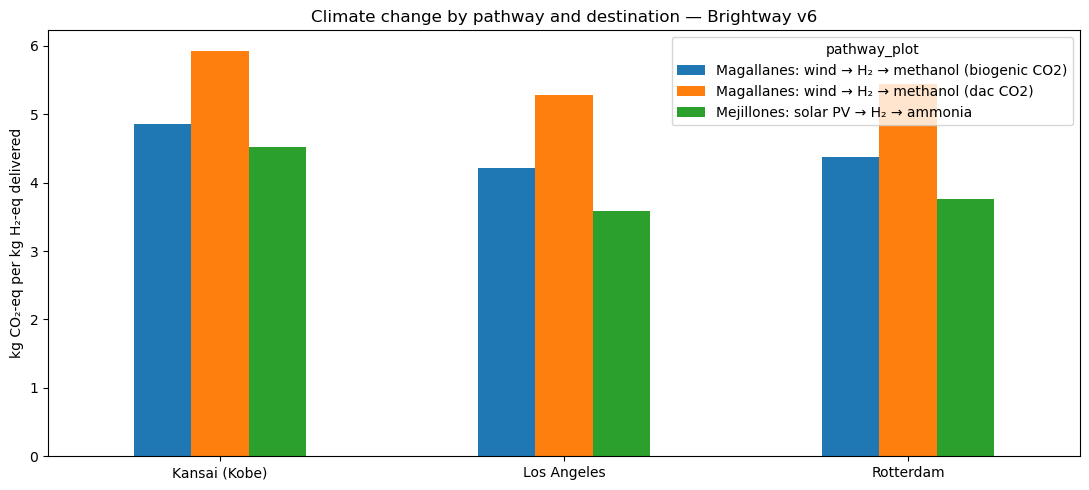

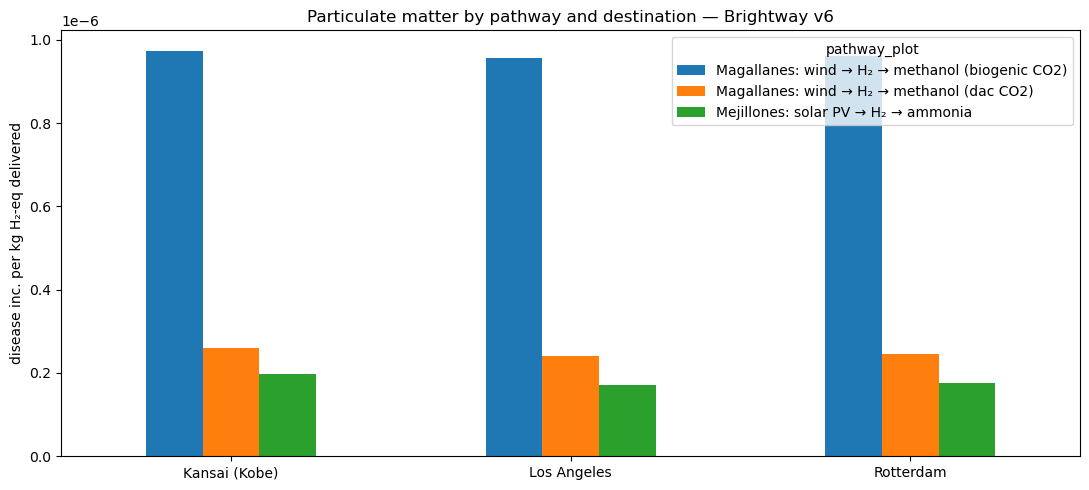

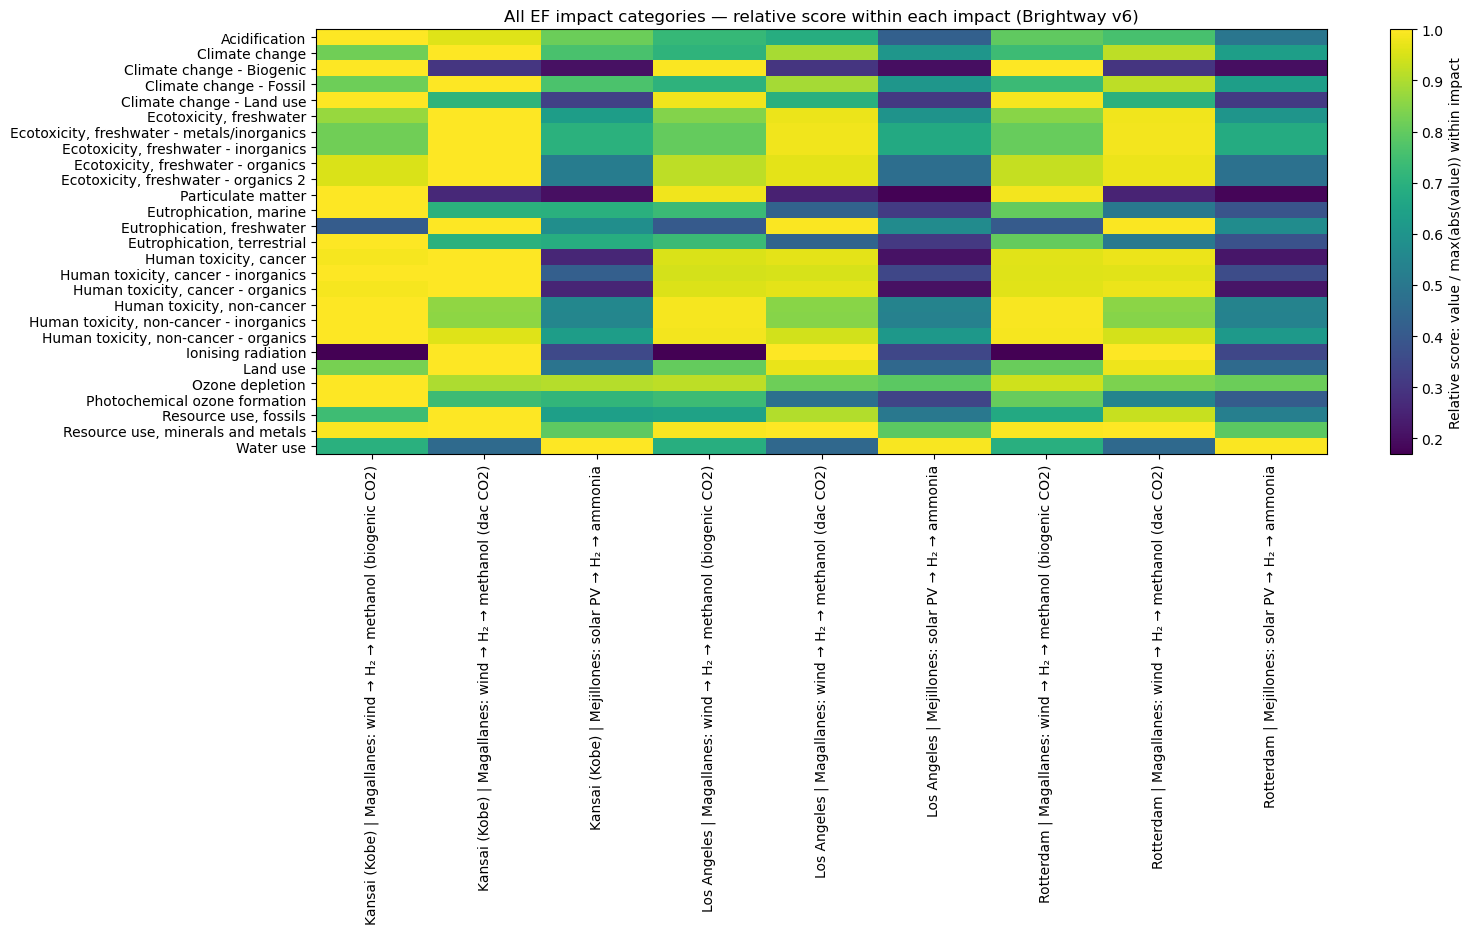

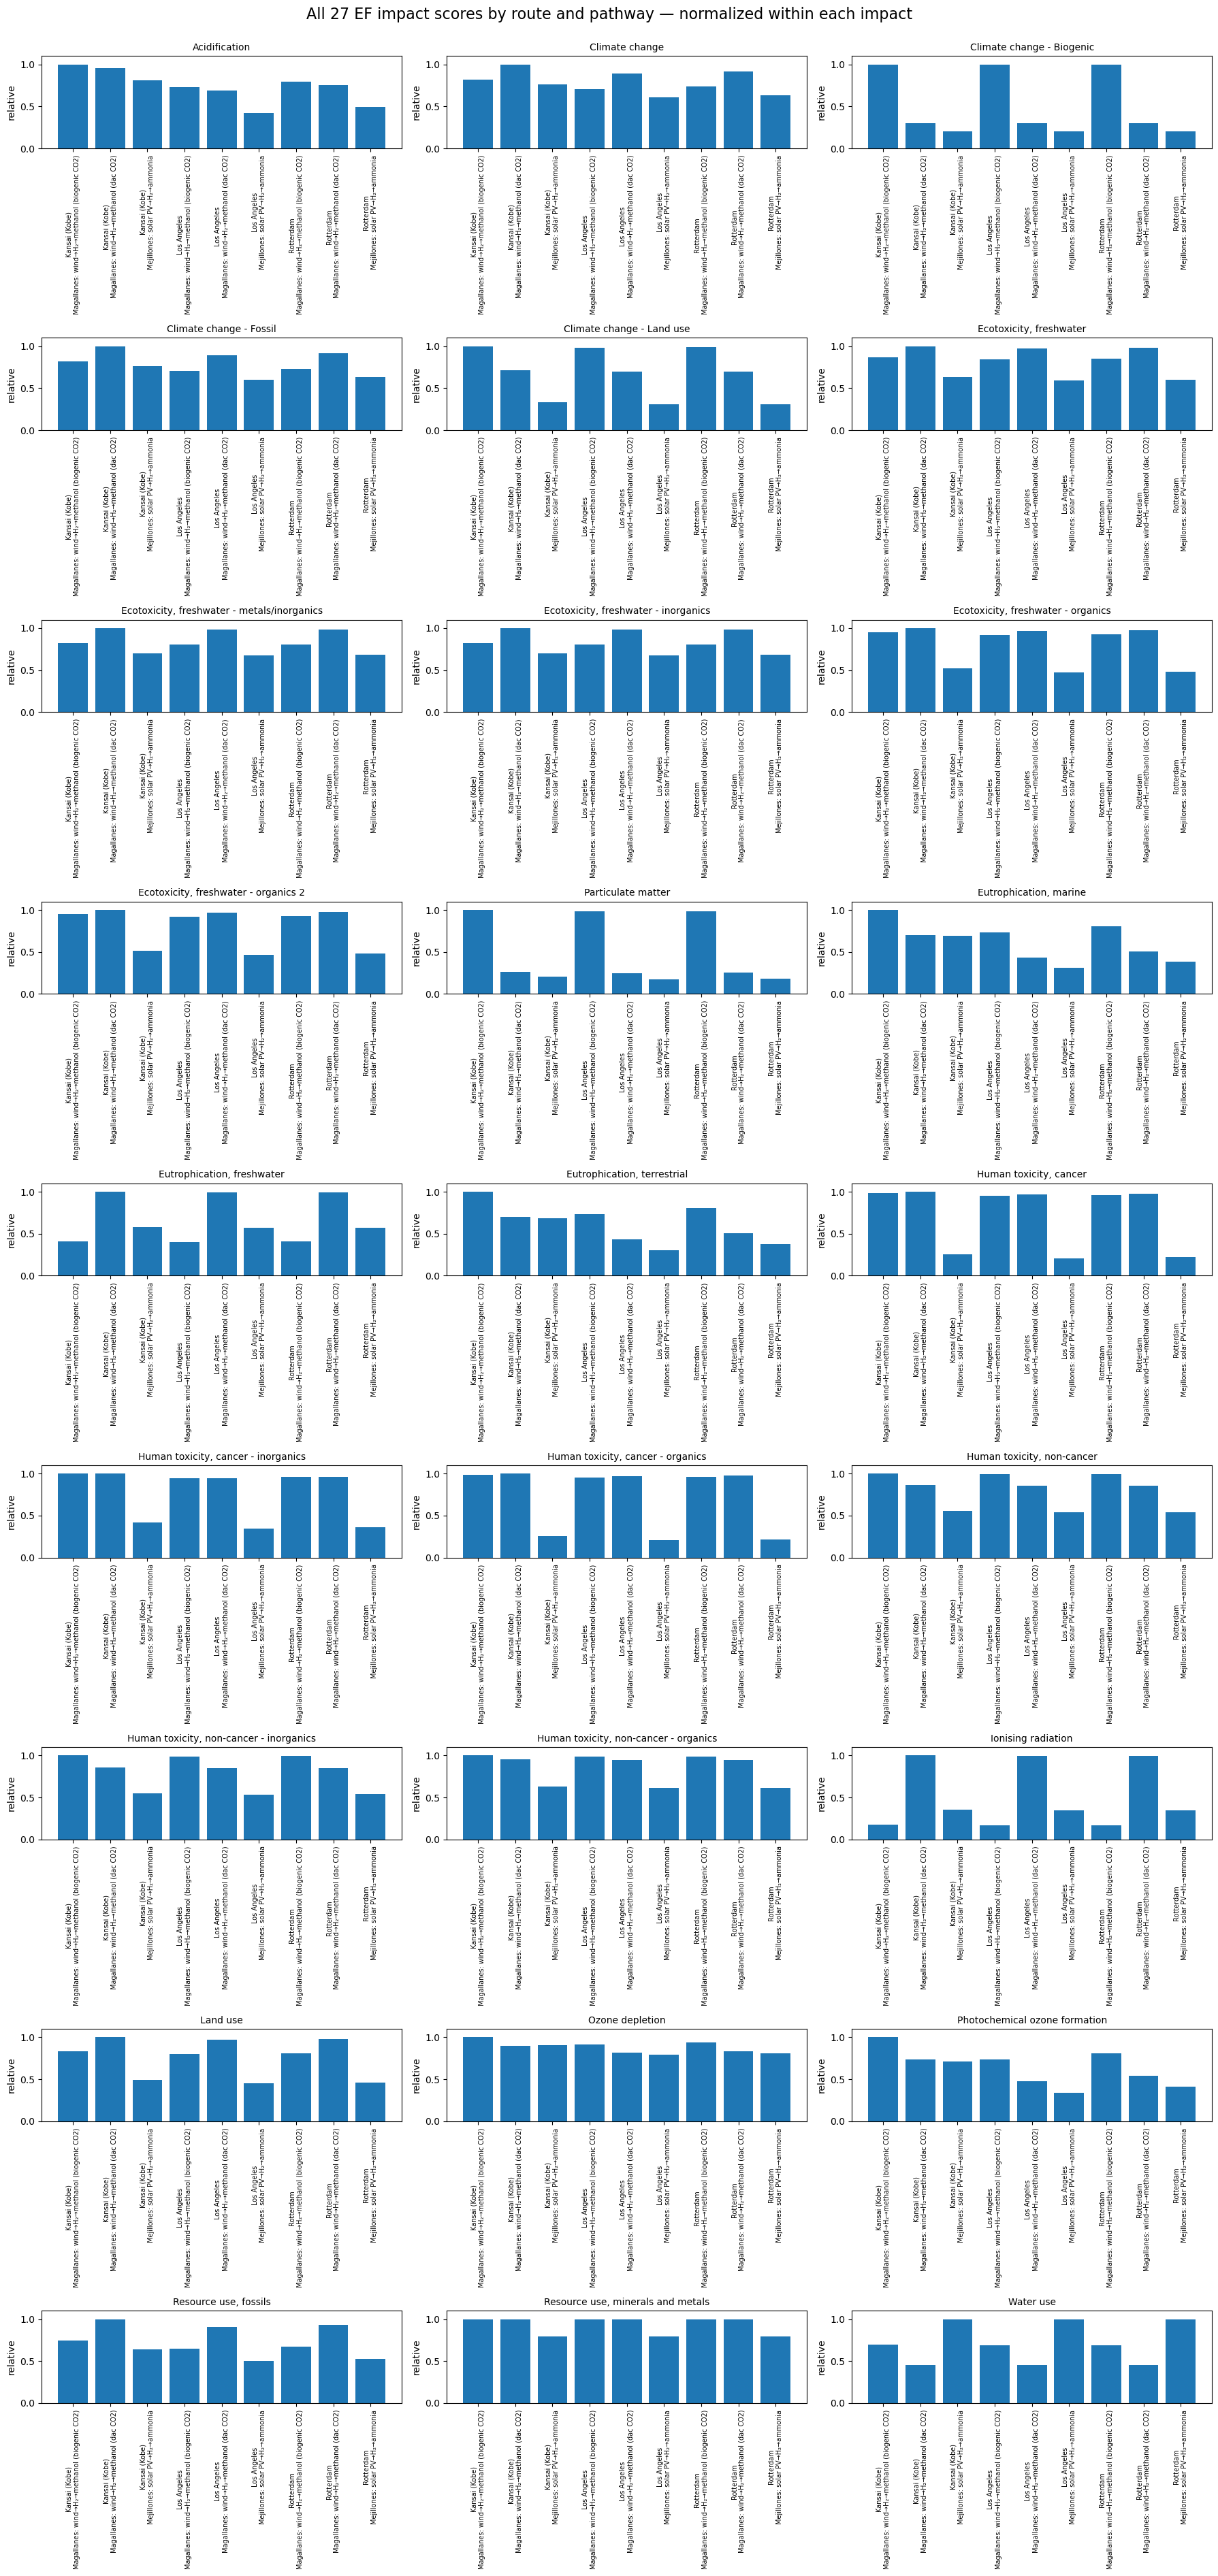

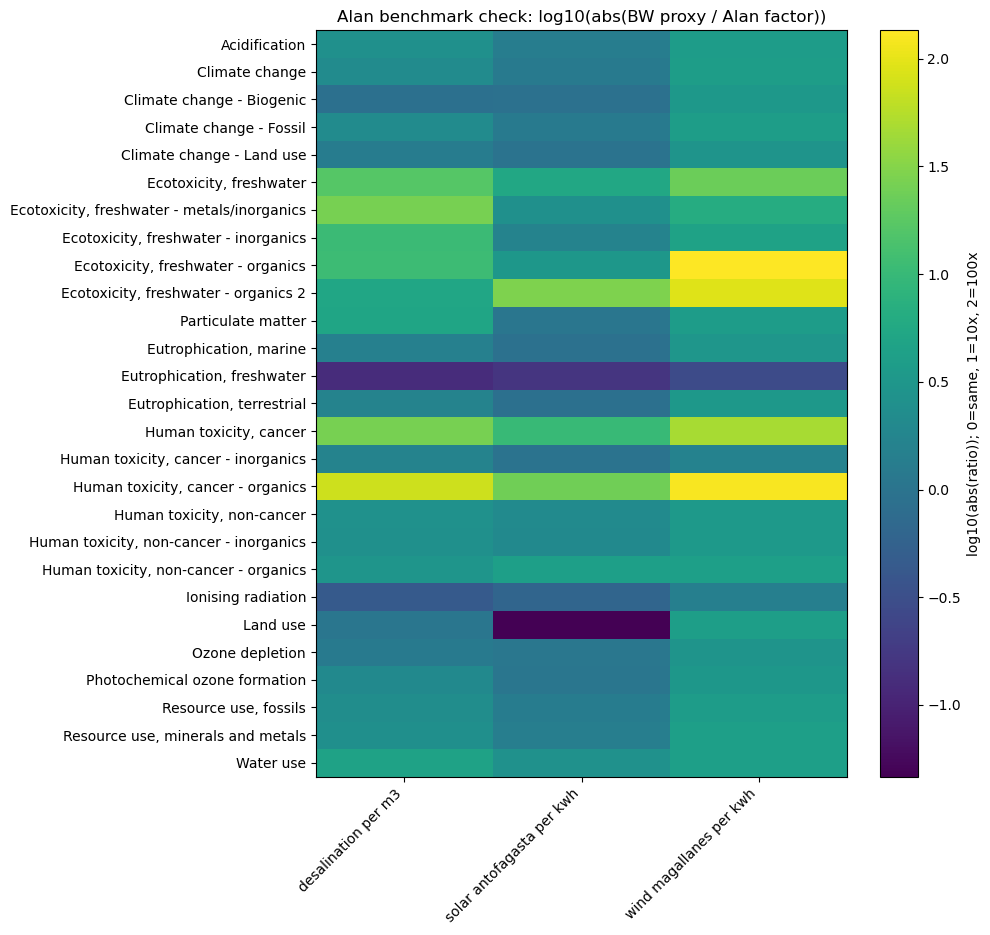

In [15]:

import matplotlib.pyplot as plt
import numpy as np

if RUN_LCIA_AFTER_BUILD and not results_df.empty:
    results_ok = results_df[results_df["status"] == "ok"].copy()
    results_ok["pathway_plot"] = results_ok["label"] + results_ok["co2_case"].fillna("").map(lambda x: f" ({x} CO2)" if x else "")
    results_ok["route_pathway"] = results_ok["destination"] + " | " + results_ok["pathway_plot"]

    # Climate change plot
    plot_df = results_ok[results_ok["impact_id"] == "climate_change"].copy()
    if not plot_df.empty:
        pivot = plot_df.pivot_table(index="destination", columns="pathway_plot", values="bw_score_per_kg_h2eq_delivered", aggfunc="first")
        ax = pivot.plot(kind="bar", figsize=(11, 5))
        ax.set_title("Climate change by pathway and destination — Brightway v6")
        ax.set_ylabel("kg CO₂-eq per kg H₂-eq delivered")
        ax.set_xlabel("")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "fig_v6_climate_change.png", dpi=200)
        plt.show()

    # Particulate matter plot
    plot_df = results_ok[results_ok["impact_id"] == "particulate_matter"].copy()
    if not plot_df.empty:
        pivot = plot_df.pivot_table(index="destination", columns="pathway_plot", values="bw_score_per_kg_h2eq_delivered", aggfunc="first")
        ax = pivot.plot(kind="bar", figsize=(11, 5))
        ax.set_title("Particulate matter by pathway and destination — Brightway v6")
        ax.set_ylabel("disease inc. per kg H₂-eq delivered")
        ax.set_xlabel("")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "fig_v6_particulate_matter.png", dpi=200)
        plt.show()

    # ============================================================
    # All 27 impact scores: normalized heatmap
    # ============================================================
    # Different EF categories have different units, so direct raw comparison is not meaningful.
    # We therefore normalize each impact row by the maximum absolute score across routes/pathways.
    all_impacts = results_ok.copy()
    all_impacts["abs_score"] = all_impacts["bw_score_per_kg_h2eq_delivered"].abs()
    max_by_impact = all_impacts.groupby("impact_id")["abs_score"].transform("max")
    all_impacts["relative_score_within_impact"] = all_impacts["bw_score_per_kg_h2eq_delivered"] / max_by_impact.replace(0, np.nan)

    heat = all_impacts.pivot_table(
        index="impact_category",
        columns="route_pathway",
        values="relative_score_within_impact",
        aggfunc="first"
    )

    # Keep Alan order
    impact_order = ALAN_FACTORS["impact_category"].tolist()
    heat = heat.reindex([x for x in impact_order if x in heat.index])

    fig, ax = plt.subplots(figsize=(16, max(8, 0.35 * len(heat))))
    im = ax.imshow(heat.values, aspect="auto")
    ax.set_title("All EF impact categories — relative score within each impact (Brightway v6)")
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(heat.columns, rotation=90)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Relative score: value / max(abs(value)) within impact")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig_v6_all_27_impacts_relative_heatmap.png", dpi=220)
    plt.show()

    # ============================================================
    # All 27 impact scores: relative bar facets
    # ============================================================
    # One small bar plot per impact, using the same relative scale.
    n_impacts = len(impact_order)
    ncols = 3
    nrows = int(np.ceil(n_impacts / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, impact_cat in zip(axes, impact_order):
        sub = all_impacts[all_impacts["impact_category"] == impact_cat].copy()
        if sub.empty:
            ax.axis("off")
            continue
        sub = sub.sort_values(["destination", "pathway_plot"])
        labels = sub["destination"].astype(str) + "\n" + sub["pathway_plot"].astype(str).str.replace(" → ", "→", regex=False)
        ax.bar(np.arange(len(sub)), sub["relative_score_within_impact"])
        ax.set_title(impact_cat, fontsize=10)
        ax.set_ylim(bottom=min(0, np.nanmin(sub["relative_score_within_impact"]) * 1.1), top=1.1)
        ax.set_xticks(np.arange(len(sub)))
        ax.set_xticklabels(labels, rotation=90, fontsize=7)
        ax.set_ylabel("relative")

    for ax in axes[n_impacts:]:
        ax.axis("off")

    fig.suptitle("All 27 EF impact scores by route and pathway — normalized within each impact", y=1.0, fontsize=16)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig_v6_all_27_impacts_relative_facets.png", dpi=220, bbox_inches="tight")
    plt.show()

    # Save normalized plotting data
    all_impacts.to_excel(OUTPUT_DIR / "bw_results_all_impacts_with_relative_scores_v6.xlsx", index=False)

    # ============================================================
    # Alan benchmark ratio plot
    # ============================================================
    if "validation_df" in globals() and not validation_df.empty:
        val = validation_df[(validation_df["status"] == "ok") & validation_df["log10_abs_bw_over_alan"].notna()].copy()
        if not val.empty:
            val["benchmark_label"] = val["benchmark"].str.replace("alan_", "", regex=False).str.replace("_", " ", regex=False)
            val["impact_label"] = val["impact_category"]
            pivot = val.pivot_table(index="impact_label", columns="benchmark_label", values="log10_abs_bw_over_alan", aggfunc="first")
            pivot = pivot.reindex([x for x in impact_order if x in pivot.index])

            fig, ax = plt.subplots(figsize=(10, max(8, 0.35 * len(pivot))))
            im = ax.imshow(pivot.values, aspect="auto")
            ax.set_title("Alan benchmark check: log10(abs(BW proxy / Alan factor))")
            ax.set_yticks(np.arange(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            ax.set_xticks(np.arange(len(pivot.columns)))
            ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
            cbar = fig.colorbar(im, ax=ax)
            cbar.set_label("log10(abs(ratio)); 0=same, 1=10x, 2=100x")
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / "fig_v6_alan_benchmark_log10_ratio.png", dpi=220)
            plt.show()


## 11. Export complete workbook

In [16]:

out_xlsx = OUTPUT_DIR / "gh2_chile_lca_brightway_v6_results.xlsx"
with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    pd.DataFrame(PROJECTS).T.to_excel(writer, sheet_name="project_parameters")
    ROUTES.to_excel(writer, sheet_name="routes", index=False)
    ALAN_FACTORS.to_excel(writer, sheet_name="alan_validation_factors", index=False)
    pd.DataFrame(CARRIER_CONVERSIONS).T.to_excel(writer, sheet_name="stoichiometry")
    selected_proxies.to_excel(writer, sheet_name="selected_proxies", index=False)
    method_mapping.to_excel(writer, sheet_name="method_mapping_manual", index=False)
    final_activities_df.to_excel(writer, sheet_name="final_activities", index=False)
    if 'results_df' in globals():
        results_df.to_excel(writer, sheet_name="bw_results", index=False)
    if 'all_impacts' in globals():
        all_impacts.to_excel(writer, sheet_name="bw_results_relative", index=False)
    if 'contrib_df' in globals():
        contrib_df.to_excel(writer, sheet_name="first_level_contrib", index=False)
    if 'validation_df' in globals():
        validation_df.to_excel(writer, sheet_name="alan_validation", index=False)
        validation_df.groupby(["benchmark", "benchmark_order_check"]).size().reset_index(name="n").to_excel(writer, sheet_name="alan_validation_summary", index=False)
print("Exported:", out_xlsx.resolve())


Exported: C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\general_LCA\outputs_v6\gh2_chile_lca_brightway_v6_results.xlsx


## 12. Notes and remaining TODOs

This v6 notebook now creates a connected Brightway foreground model. Remaining items to review:

1. **Proxy selection:** Verify selected proxy datasets in `selected_proxies_v6.xlsx` and `proxy_candidates_v6.xlsx`.
2. **EF method mapping:** Check `method_mapping_v6.xlsx`; method naming can vary across Brightway imports.
3. **CO₂ source:** DAC and biogenic CO₂ proxies may require manual selection from your old custom database or a better premise dataset.
4. **Carrier synthesis:** Current foreground synthesis uses stoichiometric feedstocks plus process electricity. Add catalysts, plant infrastructure, compression, storage, liquefaction/refrigeration if needed.
5. **Shipping:** Uses tanker proxy tonne-km. Replace with chemical/ammonia-specific tanker if your database contains better datasets.
6. **Water sensitivity:** Baseline is 10 L/kg H₂. Add a second run with 35 L/kg H₂ by changing the assumption or parameterizing both variants.
7. **Contribution analysis:** First-level contribution is included; recursive contribution can be added after proxy selection is stable.
